# GroupWork 2 - Part 1: Empirical Mode Decomposition (EMD)

Participants:

Simen Fritzner

Petter Kvam Haugan

## Signal Generation (from GroupWork1)

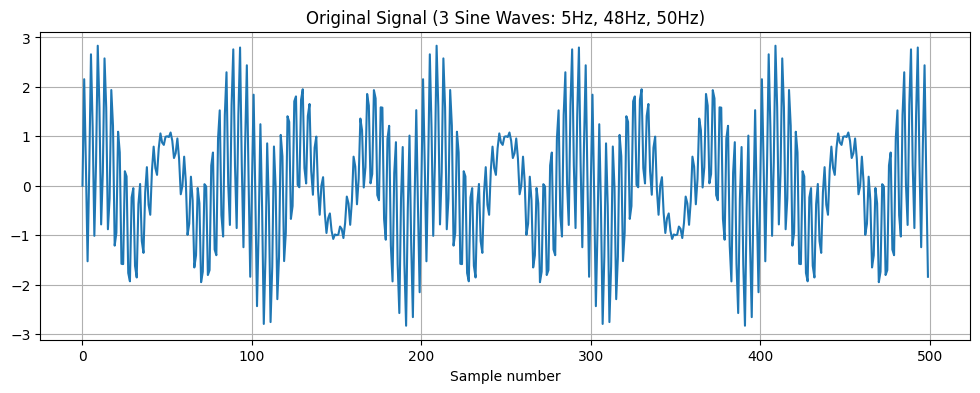

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline, PchipInterpolator
from scipy.signal import hilbert
from scipy.fft import fft, fftfreq

def generateMultiSinWave(freqs, N=512, sr=1024):
    """Generate a sum of multiple sine waves."""
    time_vector = np.arange(N) / sr
    combined_signal = np.zeros(N)  # Real signal
    
    for freq in freqs:
        combined_signal += np.sin(2 * np.pi * freq * time_vector)
    
    return combined_signal

def add_white_noise(signal, noise_level=0.2):
    """Add white Gaussian noise to signal"""
    noise = np.random.normal(0, noise_level, len(signal))
    return signal + noise

def plotSignal(signal, title='Real part of signal'):
    plt.figure(figsize=(12, 4))
    plt.plot(np.real(signal))
    plt.title(title)
    plt.xlabel('Sample number')
    plt.grid()
    plt.show()

# Generate base signal
freqs = [5, 48, 50]
sr = 200
N = 500

signal = generateMultiSinWave(freqs, N, sr)
time_vector = np.arange(N) / sr

plotSignal(signal, 'Original Signal (3 Sine Waves: 5Hz, 48Hz, 50Hz)')

## EMD Implementation - Step by Step

Empirical Mode Decomposition (EMD) is a data-driven method for decomposing non-linear and non-stationary signals into Intrinsic Mode Functions (IMFs).

Key steps in EMD:
1. **Extrema Detection**: Find all local maxima and minima in the signal
2. **Envelope Creation**: Interpolate through maxima (upper envelope) and minima (lower envelope) using spline interpolation
3. **Mean Envelope**: Calculate the mean of upper and lower envelopes
4. **Sifting**: Subtract the mean envelope from the signal to get a candidate IMF
5. **IMF Criterion Check**: Verify if the candidate satisfies IMF conditions (equal extrema/zero-crossings, symmetric envelopes)
6. **Residual**: After extracting an IMF, subtract it from the signal and repeat until residual is monotonic

The process continues until the residual becomes monotonic (no more oscillations).

In [31]:
def find_extrema(signal):
    """Find local maxima and minima in the signal."""
    maxima_idx = []
    minima_idx = []
    
    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i-1] and signal[i] > signal[i+1]:
            maxima_idx.append(i)
        elif signal[i] < signal[i-1] and signal[i] < signal[i+1]:
            minima_idx.append(i)
    
    return np.array(maxima_idx), np.array(minima_idx)

def create_envelope(signal, extrema_idx, kind='cubic'):
    """
    Create envelope by interpolating through extrema points.
    kind: 'cubic' for natural cubic spline, 'pchip' for Hermite interpolation
    """
    if len(extrema_idx) < 2:
        return None
    
    x = extrema_idx
    y = signal[extrema_idx]
    x_new = np.arange(len(signal))
    
    if kind == 'cubic':
        # Natural cubic spline
        interpolator = CubicSpline(x, y, bc_type='natural')
    elif kind == 'pchip':
        # PCHIP (Hermite) interpolation
        interpolator = PchipInterpolator(x, y)
    else:
        raise ValueError("kind must be 'cubic' or 'pchip'")
    
    return interpolator(x_new)

def visualize_sifting_step(signal, time_vector, maxima_idx, minima_idx, 
                          upper_env, lower_env, mean_env, imf_num, sift_num):
    """Visualize a single sifting step with extrema and envelopes."""
    plt.figure(figsize=(14, 6))
    
    # Plot signal
    plt.plot(time_vector, signal, 'b-', label='Signal', linewidth=1.5)
    
    # Plot extrema
    if len(maxima_idx) > 0:
        plt.plot(time_vector[maxima_idx], signal[maxima_idx], 'ro', 
                label='Maxima', markersize=6)
    if len(minima_idx) > 0:
        plt.plot(time_vector[minima_idx], signal[minima_idx], 'go', 
                label='Minima', markersize=6)
    
    # Plot envelopes
    if upper_env is not None:
        plt.plot(time_vector, upper_env, 'r--', label='Upper Envelope', linewidth=1)
    if lower_env is not None:
        plt.plot(time_vector, lower_env, 'g--', label='Lower Envelope', linewidth=1)
    if mean_env is not None:
        plt.plot(time_vector, mean_env, 'k--', label='Mean Envelope', linewidth=2)
    
    plt.title(f'IMF {imf_num} - Sifting Step {sift_num}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def check_imf_criterion(signal, sd_threshold=0.3):
    """
    Check if signal satisfies IMF criterion using Standard Deviation (SD).
    SD = sum((h_{k-1} - h_k)^2 / h_{k-1}^2)
    """
    if np.all(signal == 0):
        return True, 0.0
    
    sd = np.sum(signal**2) / (np.sum(signal**2) + 1e-10)
    return sd < sd_threshold, sd

def sift_process(signal, time_vector, max_sifts=10, spline_type='cubic', 
                use_default_stopping=False, visualize_steps=False, imf_num=1):
    """
    Perform sifting process to extract one IMF.
    
    Parameters:
    - signal: input signal
    - time_vector: time axis
    - max_sifts: maximum number of sifting iterations (used if use_default_stopping=False)
    - spline_type: 'cubic' or 'pchip'
    - use_default_stopping: if True, use SD criterion; if False, use fixed iterations
    - visualize_steps: if True, show visualization for each sift
    - imf_num: IMF number for labeling
    """
    h = signal.copy()
    
    for sift_iter in range(max_sifts if not use_default_stopping else 100):
        # Find extrema
        maxima_idx, minima_idx = find_extrema(h)
        
        # Check if we have enough extrema
        if len(maxima_idx) < 2 or len(minima_idx) < 2:
            break
        
        # Create envelopes
        upper_env = create_envelope(h, maxima_idx, kind=spline_type)
        lower_env = create_envelope(h, minima_idx, kind=spline_type)
        
        if upper_env is None or lower_env is None:
            break
        
        # Calculate mean envelope
        mean_env = (upper_env + lower_env) / 2
        
        # Visualize if requested (only first sift for first IMF)
        if visualize_steps and sift_iter == 0:
            visualize_sifting_step(h, time_vector, maxima_idx, minima_idx,
                                  upper_env, lower_env, mean_env, imf_num, sift_iter + 1)
        
        # Subtract mean envelope
        h_prev = h.copy()
        h = h - mean_env
        
        # Check stopping criterion
        if use_default_stopping:
            # Calculate SD between successive sifts
            sd = np.sum((h_prev - h)**2) / (np.sum(h_prev**2) + 1e-10)
            if sd < 0.3:  # SD threshold
                break
        else:
            # Fixed number of iterations
            if sift_iter >= max_sifts - 1:
                break
    
    return h

def is_monotonic(signal):
    """Check if signal is monotonic (residual condition)."""
    maxima_idx, minima_idx = find_extrema(signal)
    # Monotonic if total extrema <= 2
    return len(maxima_idx) + len(minima_idx) <= 2

def emd(signal, time_vector, max_imfs=10, max_sifts=10, spline_type='cubic',
       use_default_stopping=False, visualize_first_imf=False):
    """
    Perform complete EMD on signal.
    
    Parameters:
    - signal: input signal
    - time_vector: time axis
    - max_imfs: maximum number of IMFs to extract
    - max_sifts: maximum sifting iterations per IMF (if not using default stopping)
    - spline_type: 'cubic' for natural cubic spline, 'pchip' for Hermite
    - use_default_stopping: if True, use SD criterion; if False, use fixed sifts
    - visualize_first_imf: if True, visualize first sifting step of first IMF
    
    Returns:
    - imfs: list of IMFs
    - residue: final residual
    """
    imfs = []
    residue = signal.copy()
    
    for imf_idx in range(max_imfs):
        # Check if residue is monotonic
        if is_monotonic(residue):
            break
        # Extract IMF
        visualize = visualize_first_imf and imf_idx == 0

        if imf_idx == 0:
            imf = seperateModeMix(signal, time_vector, visualize, imf_idx)
        else:
            imf = sift_process(residue, time_vector, max_sifts=max_sifts,
                            spline_type=spline_type, 
                            use_default_stopping=use_default_stopping,
                            visualize_steps=visualize, imf_num=imf_idx + 1)
        
        imfs.append(imf)
        residue = residue - imf
        
        # Safety check
        if np.all(imf == 0):
            break
    
    return imfs, residue

def seperateModeMix(signal, time_vector, visualize, imf_idx, max_sifts=10, spline_type='cubic', use_default_stopping=False, a0 = 2.0, f0 = 98):
    
    mask = a0 * np.sin(2 * np.pi * f0 * time_vector)

    signal_pluss = signal + mask

    signal_minus = signal - mask

    imf_pluss = sift_process(signal_pluss, time_vector, max_sifts=max_sifts,
                          spline_type=spline_type, 
                          use_default_stopping=use_default_stopping,
                          visualize_steps=visualize, imf_num=imf_idx + 1)
    
    imf_minus = sift_process(signal_minus, time_vector, max_sifts=max_sifts,
                          spline_type=spline_type, 
                          use_default_stopping=use_default_stopping,
                          visualize_steps=visualize, imf_num=imf_idx + 1)
    
    return (imf_pluss + imf_minus) / 2


def plot_imfs(imfs, residue, time_vector, title_prefix="EMD Decomposition"):
    """Plot all IMFs and residue."""
    n_plots = len(imfs) + 1
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2*n_plots))
    
    if n_plots == 1:
        axes = [axes]
    
    for i, imf in enumerate(imfs):
        axes[i].plot(time_vector, imf, 'b-', linewidth=1)
        axes[i].set_ylabel(f'IMF {i+1}')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim([time_vector[0], time_vector[-1]])
    
    axes[-1].plot(time_vector, residue, 'r-', linewidth=1)
    axes[-1].set_ylabel('Residue')
    axes[-1].set_xlabel('Time (s)')
    axes[-1].grid(True, alpha=0.3)
    axes[-1].set_xlim([time_vector[0], time_vector[-1]])
    
    plt.suptitle(title_prefix, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()
    
    return len(imfs)

## 1. EMD with Natural Cubic Spline - Fixed 10 Sifts

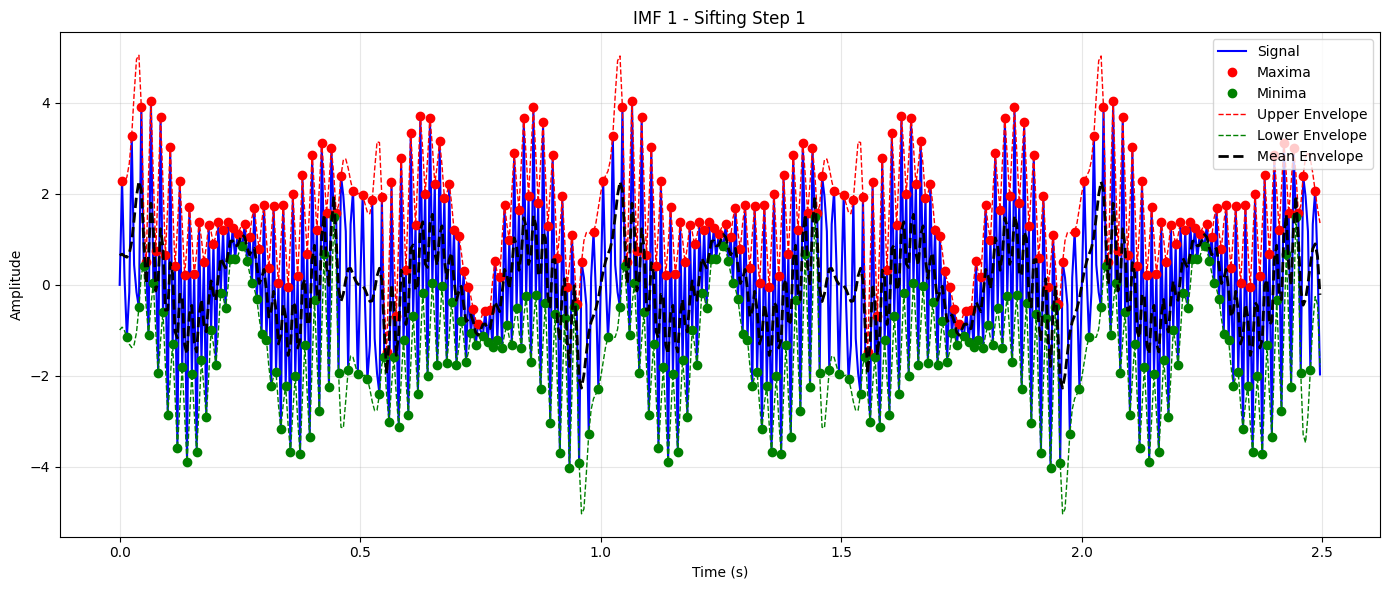

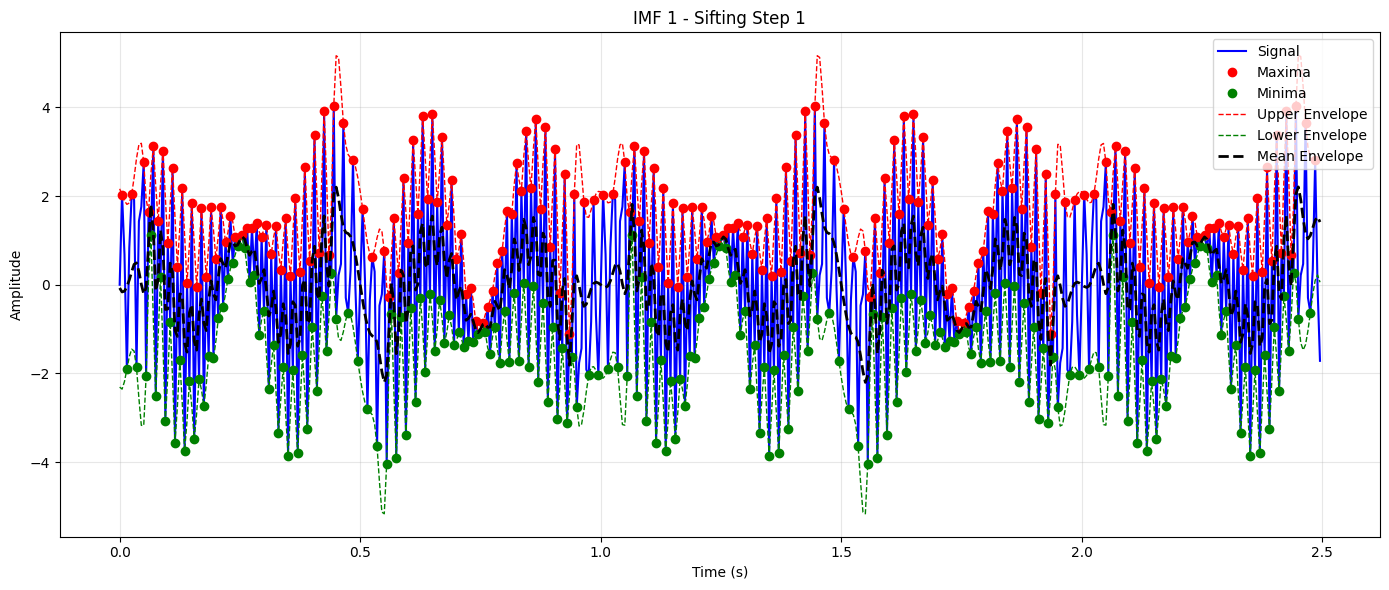

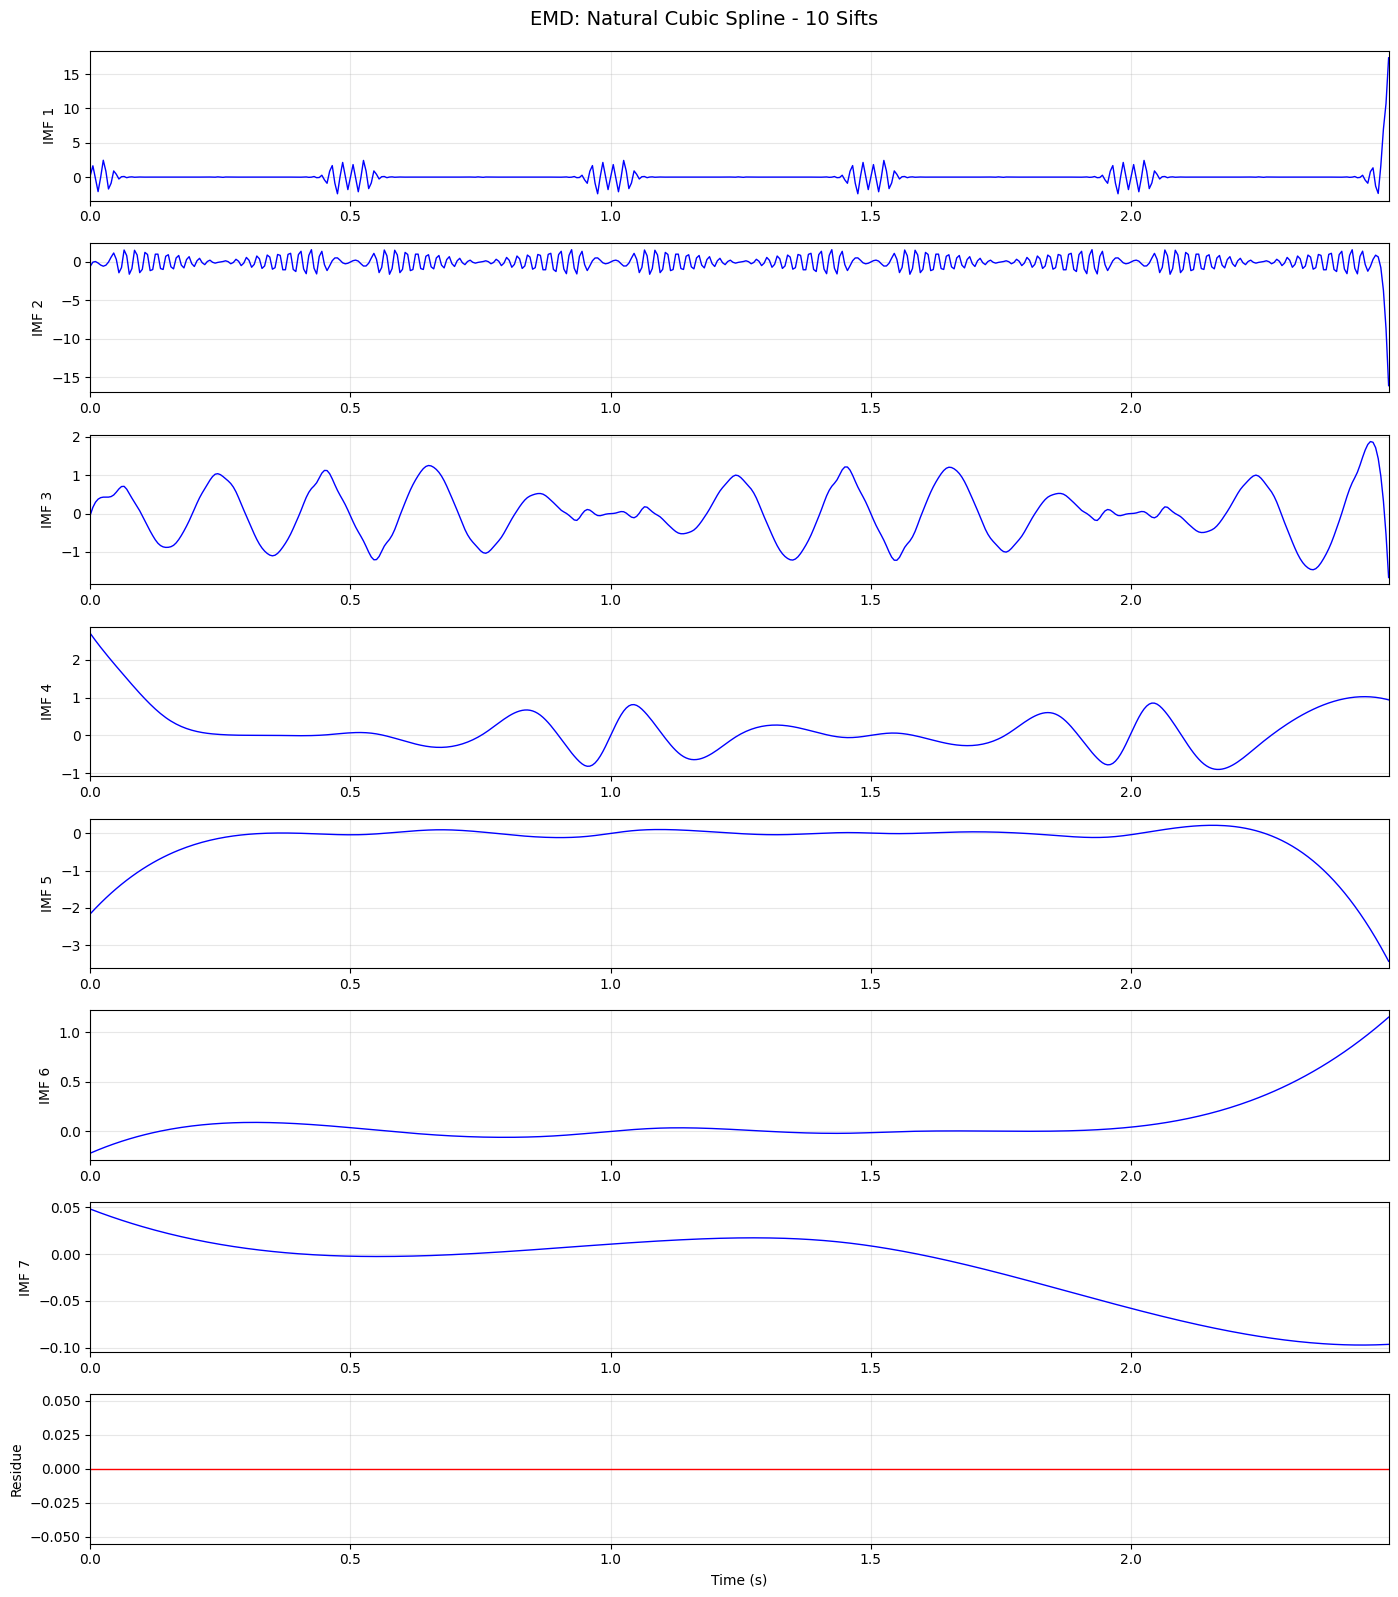

Number of IMFs extracted: 7


In [32]:
# EMD with Natural Cubic Spline, 10 sifts
imfs_cubic_10, residue_cubic_10 = emd(signal, time_vector, max_sifts=10, 
                                       spline_type='cubic', 
                                       use_default_stopping=False,
                                       visualize_first_imf=True)

n_imfs = plot_imfs(imfs_cubic_10, residue_cubic_10, time_vector, 
                   "EMD: Natural Cubic Spline - 10 Sifts")
print(f"Number of IMFs extracted: {n_imfs}")

## 2. EMD with Natural Cubic Spline - Default Stopping Criterion

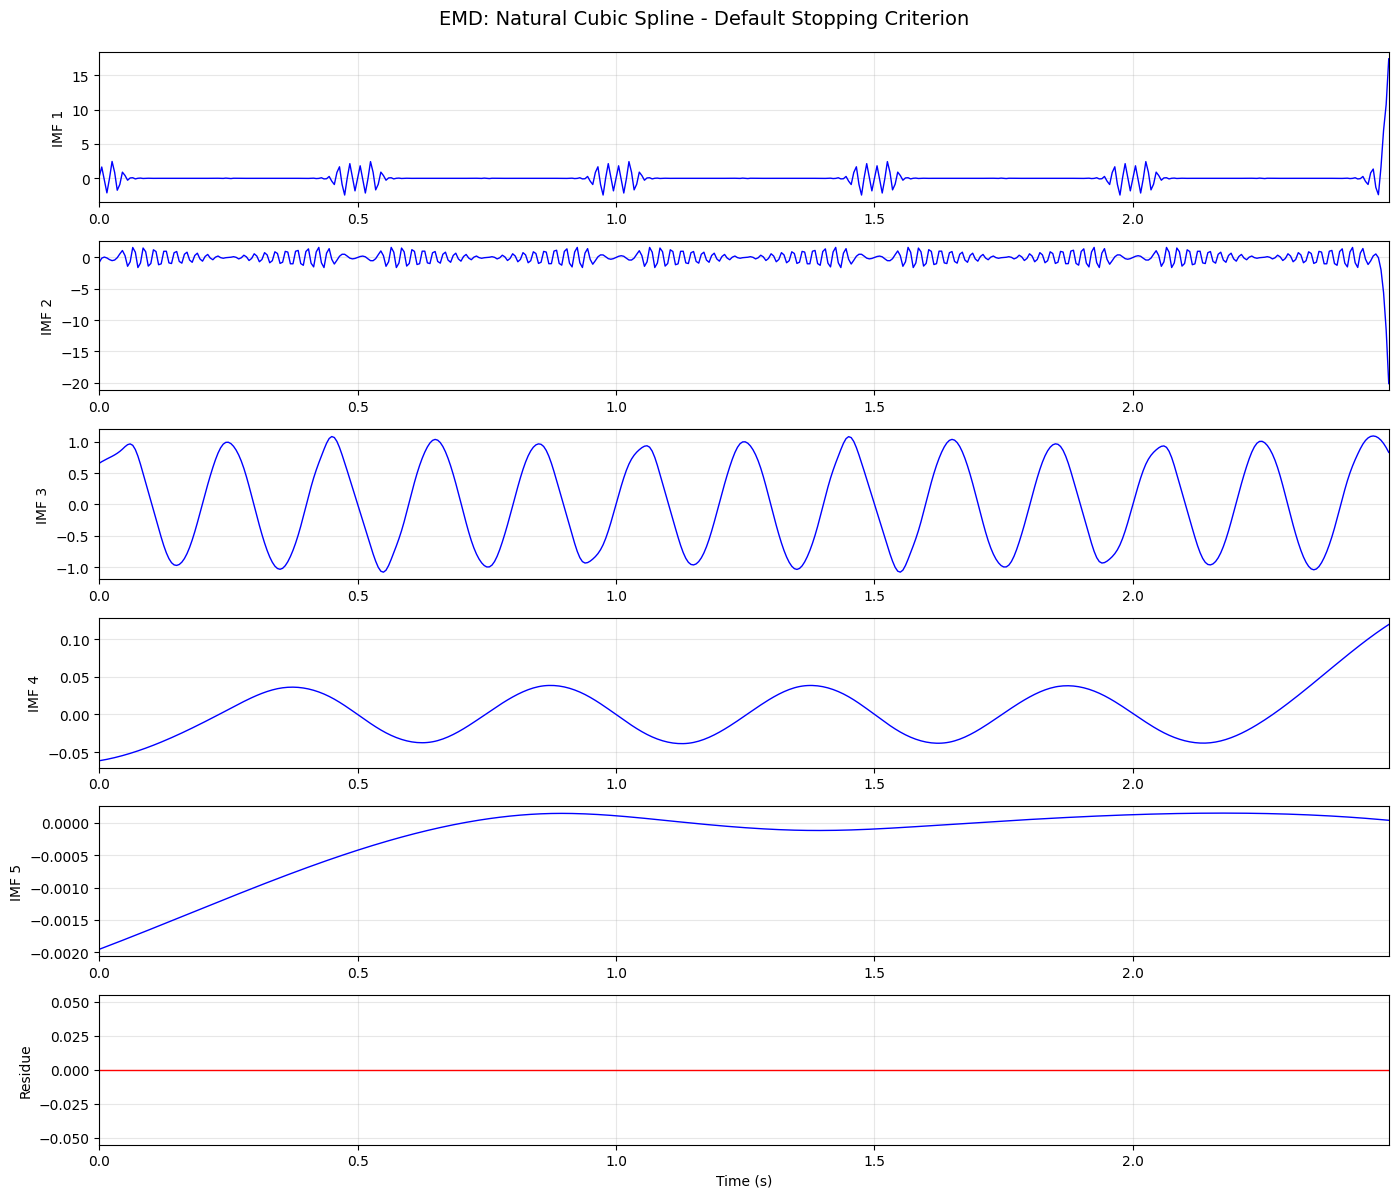

Number of IMFs extracted: 5


In [33]:
# EMD with Natural Cubic Spline, default stopping (SD < 0.3)
imfs_cubic_default, residue_cubic_default = emd(signal, time_vector, 
                                                 spline_type='cubic',
                                                 use_default_stopping=True)

n_imfs = plot_imfs(imfs_cubic_default, residue_cubic_default, time_vector,
                   "EMD: Natural Cubic Spline - Default Stopping Criterion")
print(f"Number of IMFs extracted: {n_imfs}")

## 3. EMD with Hermite (PCHIP) Spline - Fixed 10 Sifts

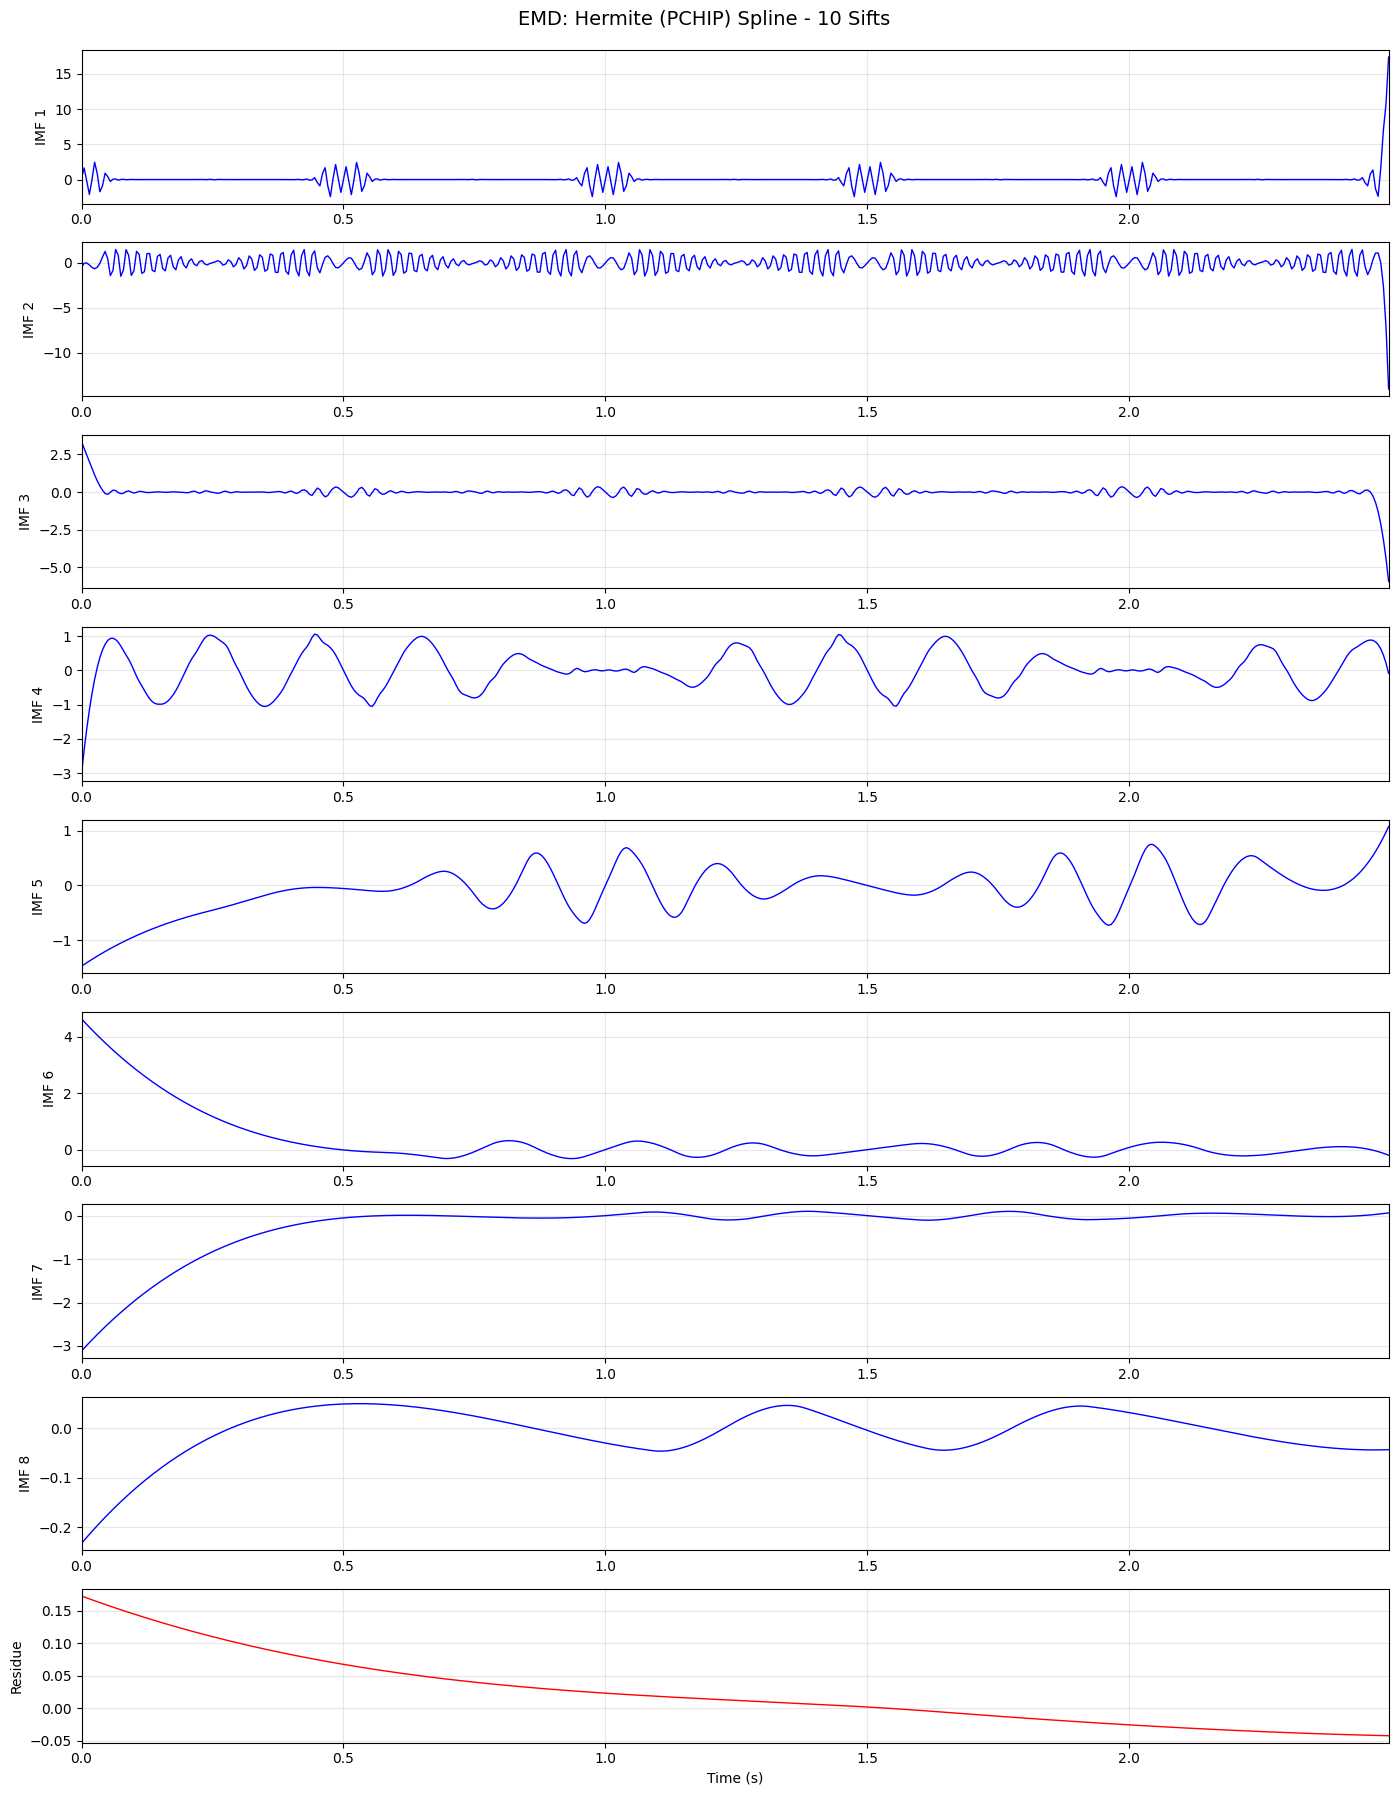

Number of IMFs extracted: 8


In [34]:
# EMD with Hermite (PCHIP) Spline, 10 sifts
imfs_pchip_10, residue_pchip_10 = emd(signal, time_vector, max_sifts=10,
                                       spline_type='pchip',
                                       use_default_stopping=False)

n_imfs = plot_imfs(imfs_pchip_10, residue_pchip_10, time_vector,
                   "EMD: Hermite (PCHIP) Spline - 10 Sifts")
print(f"Number of IMFs extracted: {n_imfs}")

## 4. EMD with Hermite (PCHIP) Spline - Default Stopping Criterion

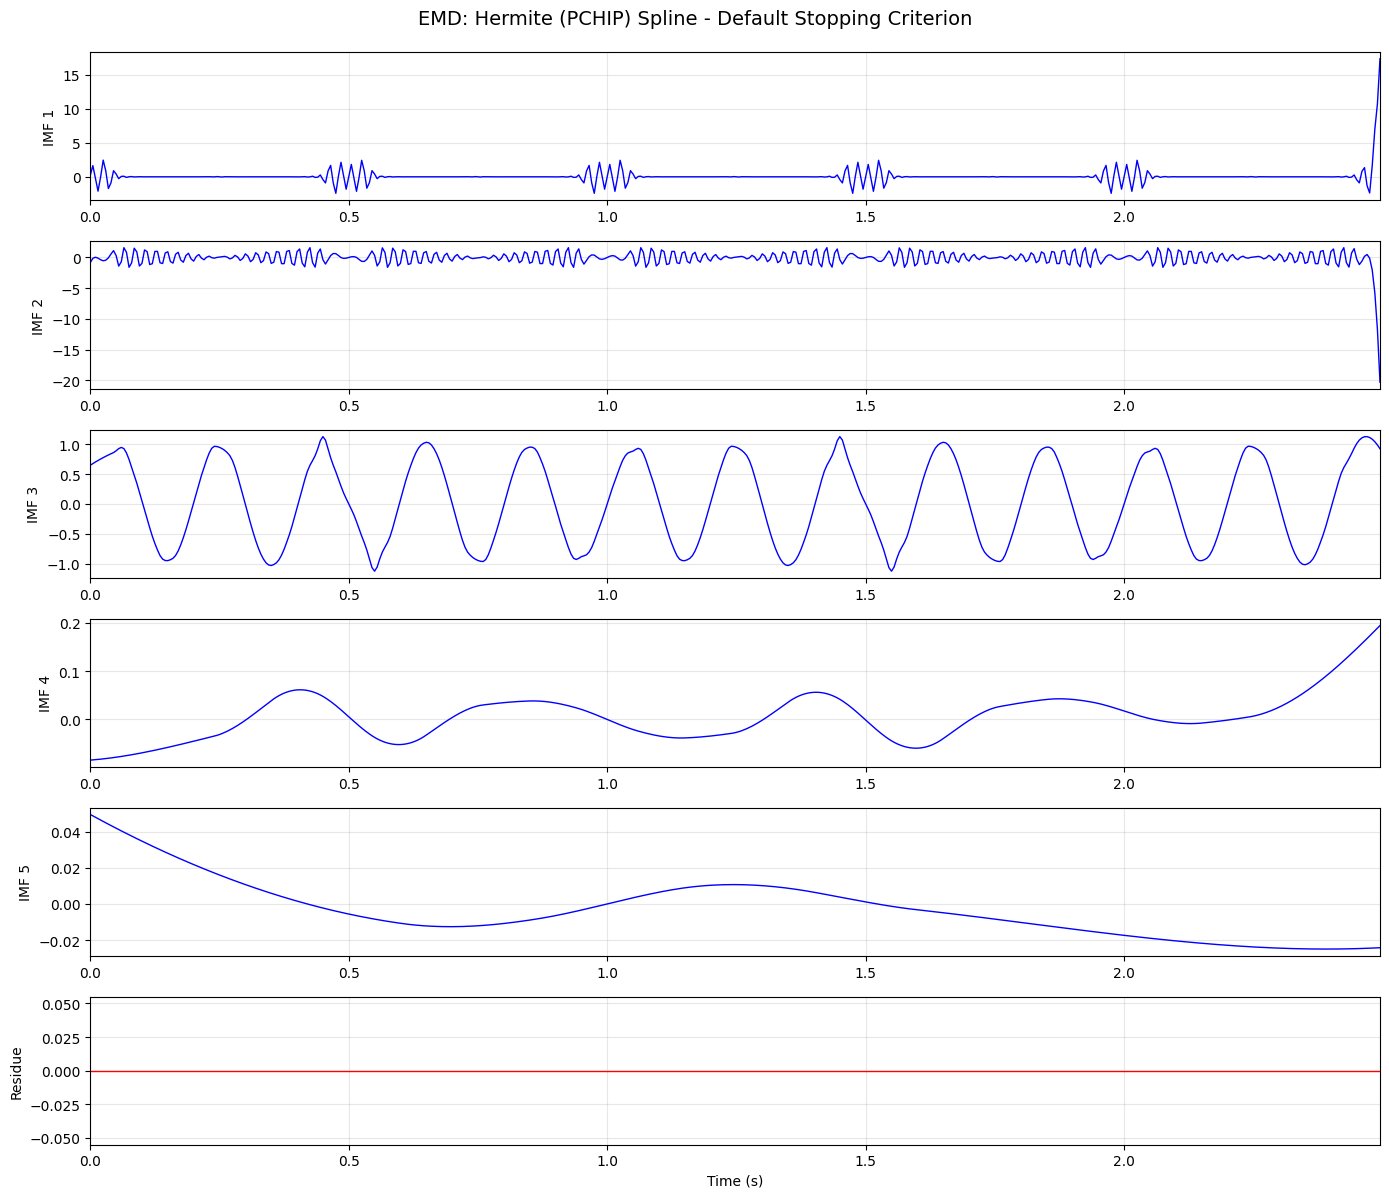

Number of IMFs extracted: 5


In [35]:
# EMD with Hermite (PCHIP) Spline, default stopping (SD < 0.3)
imfs_pchip_default, residue_pchip_default = emd(signal, time_vector,
                                                 spline_type='pchip',
                                                 use_default_stopping=True)

n_imfs = plot_imfs(imfs_pchip_default, residue_pchip_default, time_vector,
                   "EMD: Hermite (PCHIP) Spline - Default Stopping Criterion")
print(f"Number of IMFs extracted: {n_imfs}")

## FFT Analysis of IMFs

1. Natural Cubic Spline - 10 Sifts:


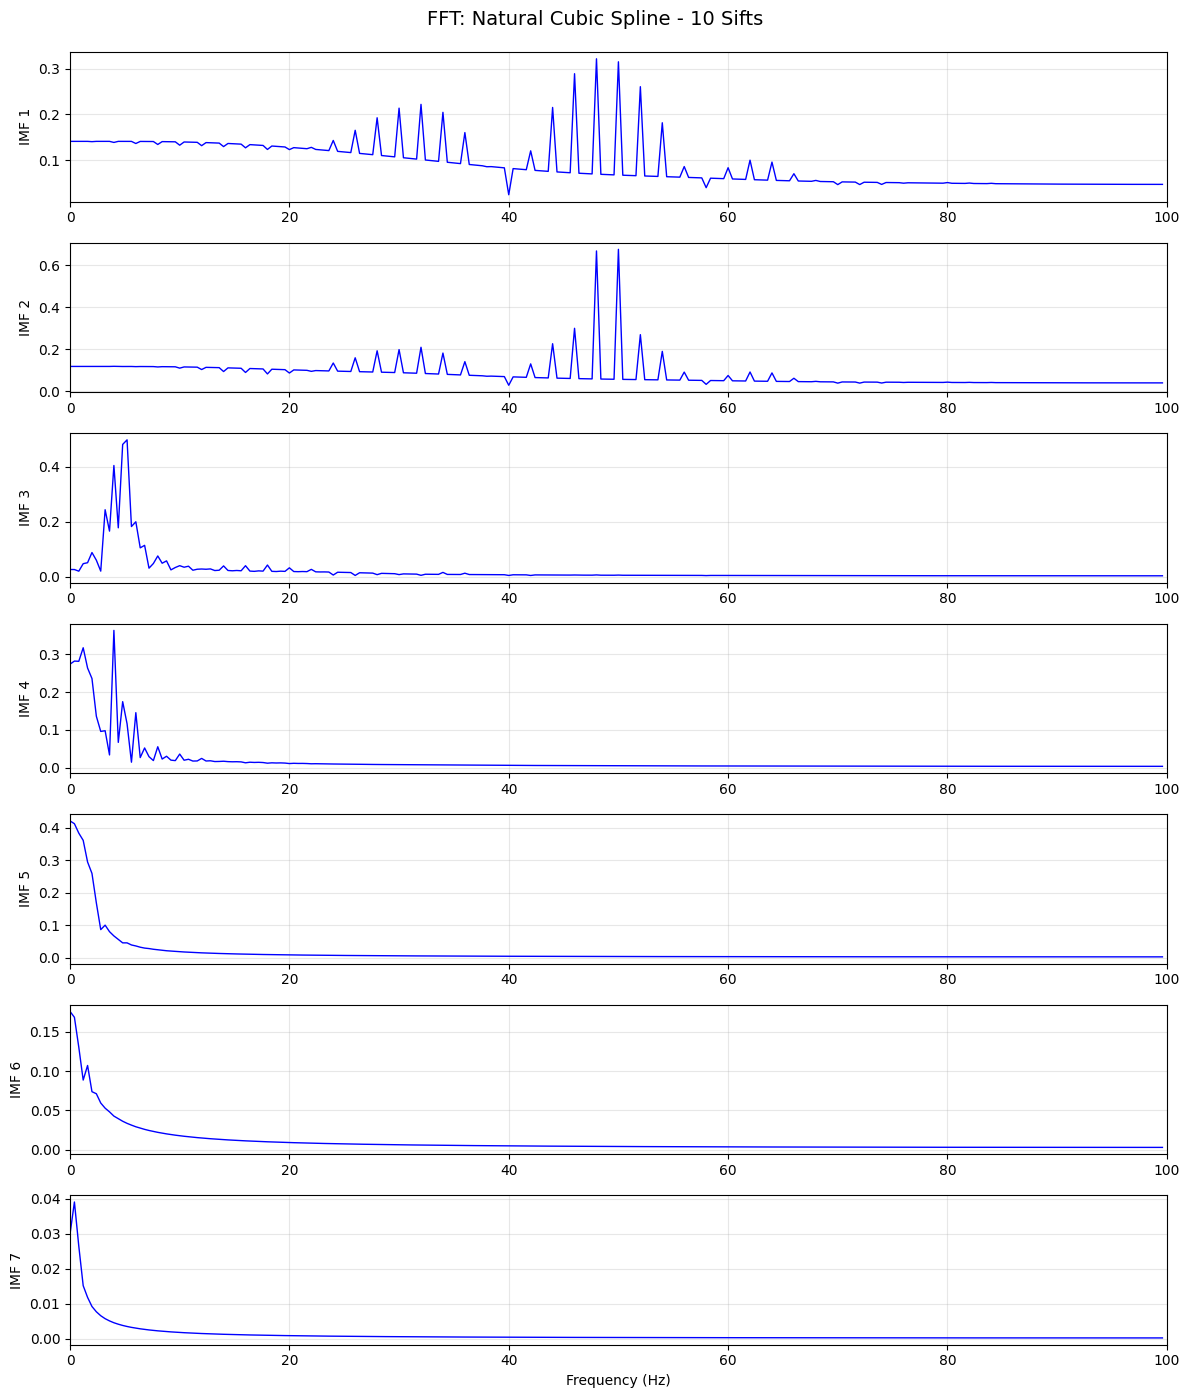


2. Natural Cubic Spline - Default Stopping:


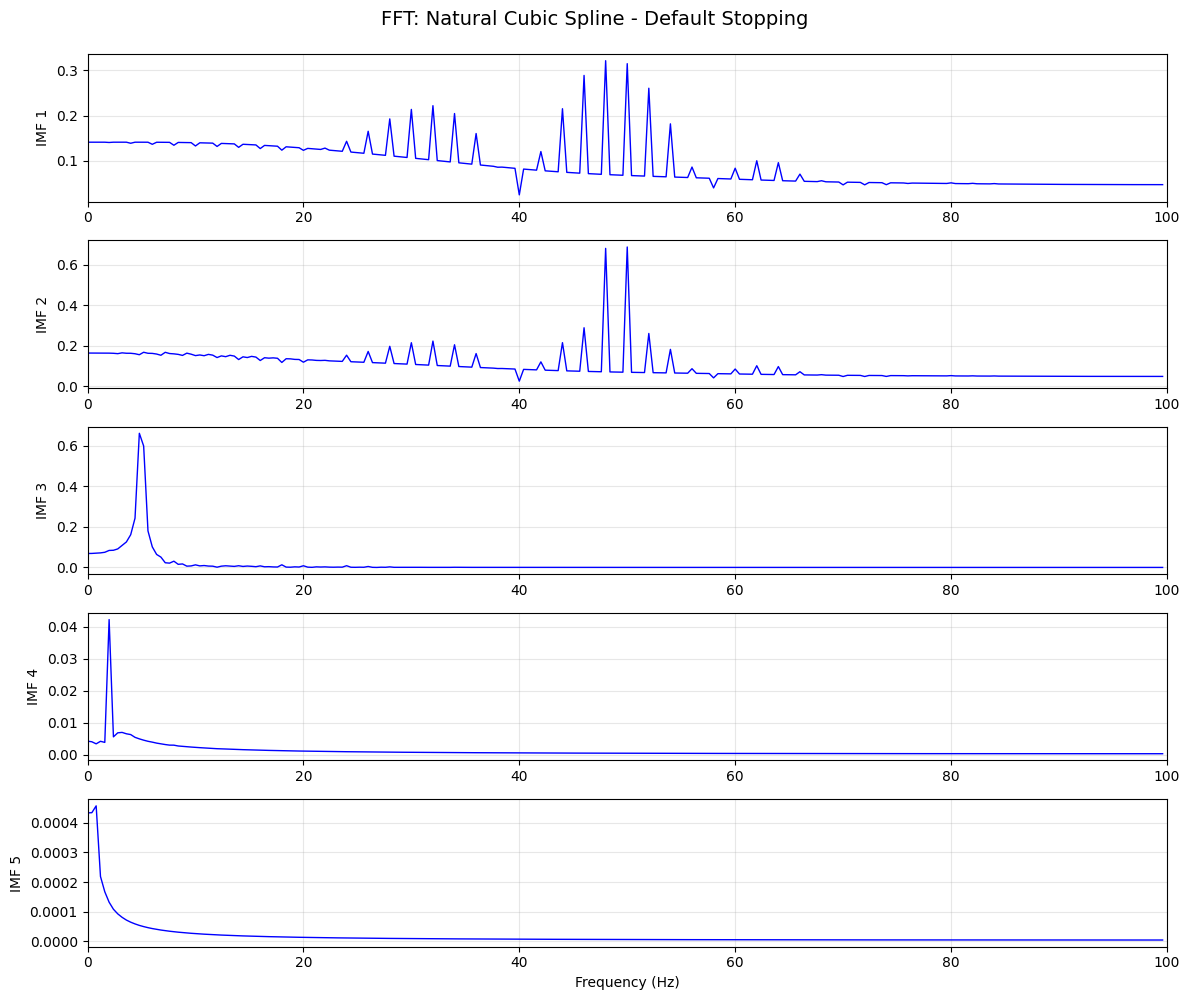


3. Hermite (PCHIP) Spline - 10 Sifts:


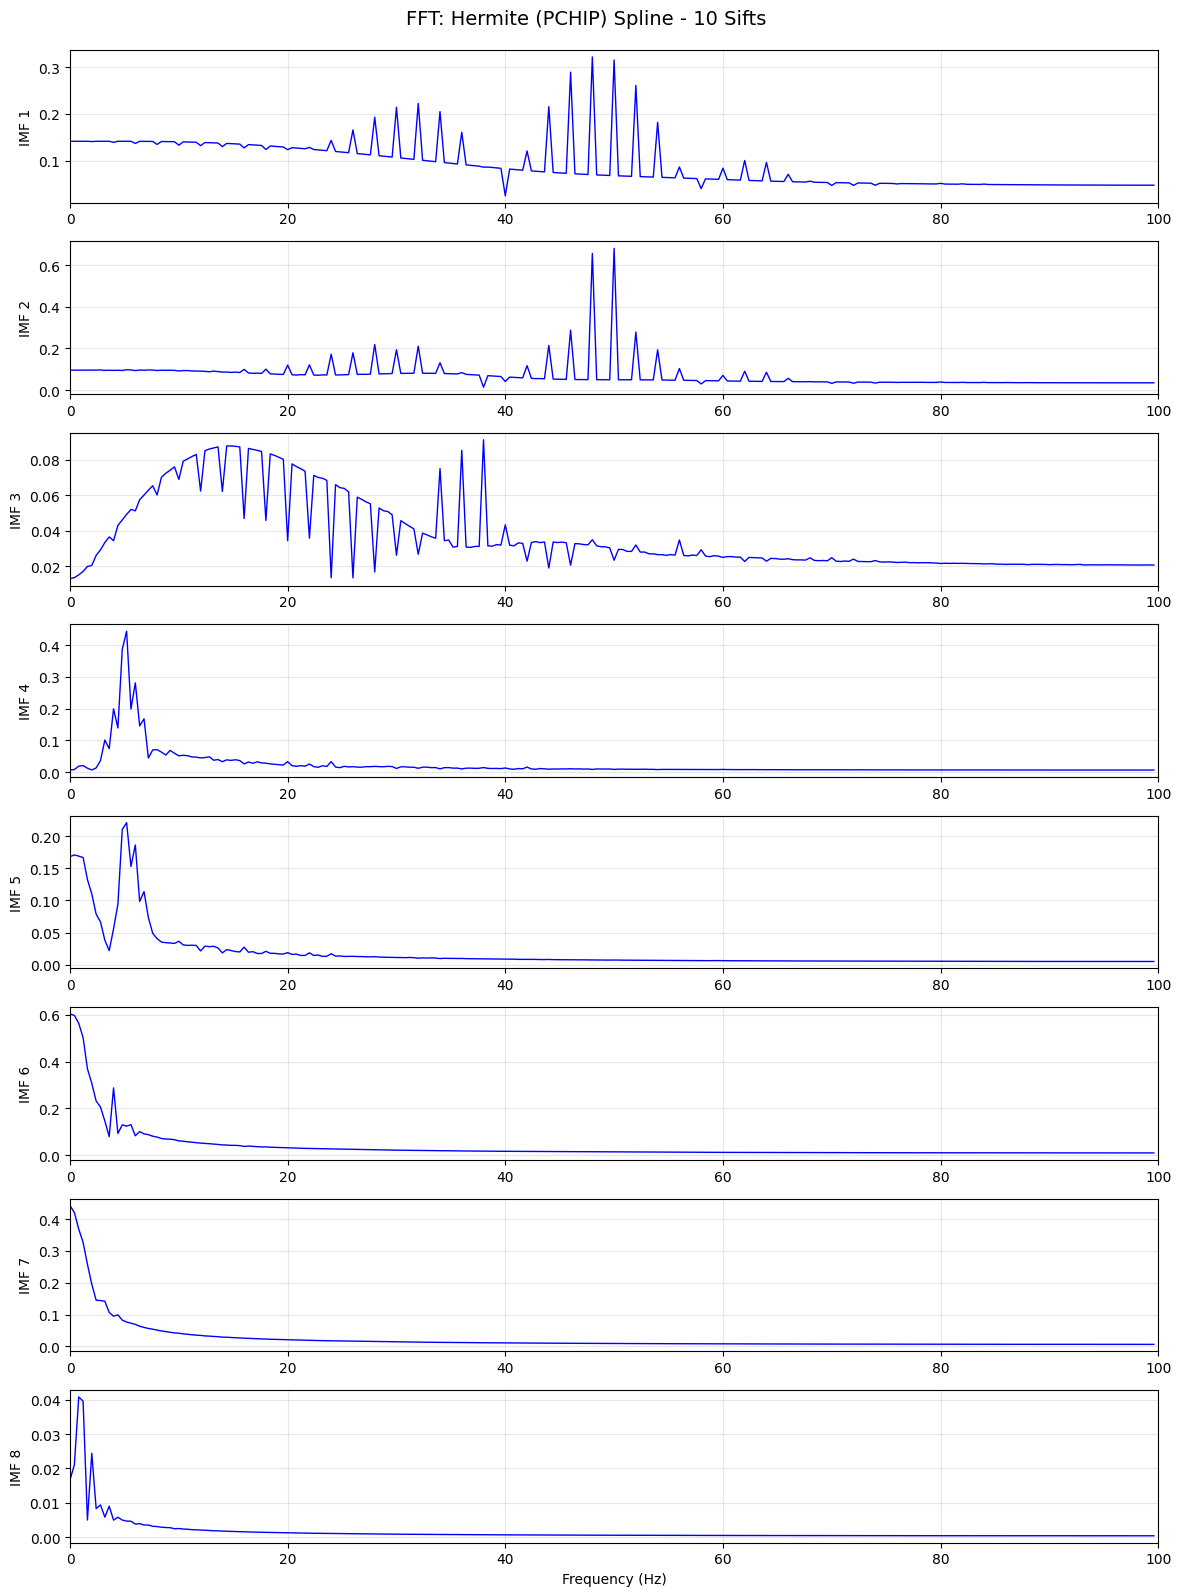


4. Hermite (PCHIP) Spline - Default Stopping:


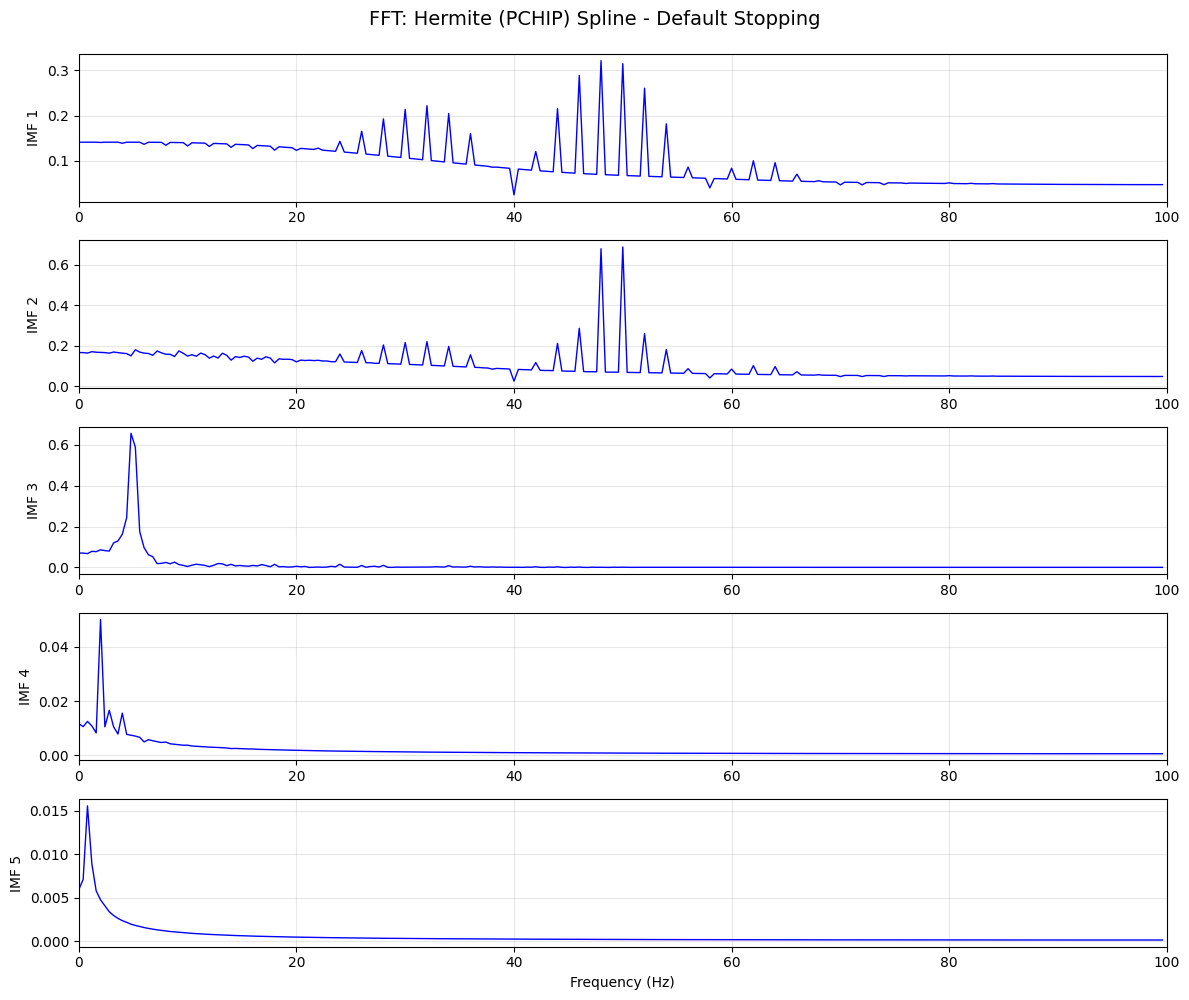

In [36]:
def compute_fft(signal, sr):
    """Compute FFT of a signal."""
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/sr)[:N//2]
    return xf, 2.0/N * np.abs(yf[:N//2])

def plot_imf_ffts(imfs, sr, title_prefix="FFT of IMFs"):
    """Plot FFT for all IMFs."""
    n_imfs = len(imfs)
    fig, axes = plt.subplots(n_imfs, 1, figsize=(12, 2*n_imfs))
    
    if n_imfs == 1:
        axes = [axes]
    
    for i, imf in enumerate(imfs):
        xf, yf = compute_fft(imf, sr)
        axes[i].plot(xf, yf, 'b-', linewidth=1)
        axes[i].set_ylabel(f'IMF {i+1}')
        axes[i].set_xlim([0, 100])
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Frequency (Hz)')
    plt.suptitle(title_prefix, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

# Plot FFTs for all 4 conditions
print("1. Natural Cubic Spline - 10 Sifts:")
plot_imf_ffts(imfs_cubic_10, sr, "FFT: Natural Cubic Spline - 10 Sifts")

print("\n2. Natural Cubic Spline - Default Stopping:")
plot_imf_ffts(imfs_cubic_default, sr, "FFT: Natural Cubic Spline - Default Stopping")

print("\n3. Hermite (PCHIP) Spline - 10 Sifts:")
plot_imf_ffts(imfs_pchip_10, sr, "FFT: Hermite (PCHIP) Spline - 10 Sifts")

print("\n4. Hermite (PCHIP) Spline - Default Stopping:")
plot_imf_ffts(imfs_pchip_default, sr, "FFT: Hermite (PCHIP) Spline - Default Stopping")

## Hilbert Transform - Instantaneous Frequency Analysis

1. Natural Cubic Spline - 10 Sifts:


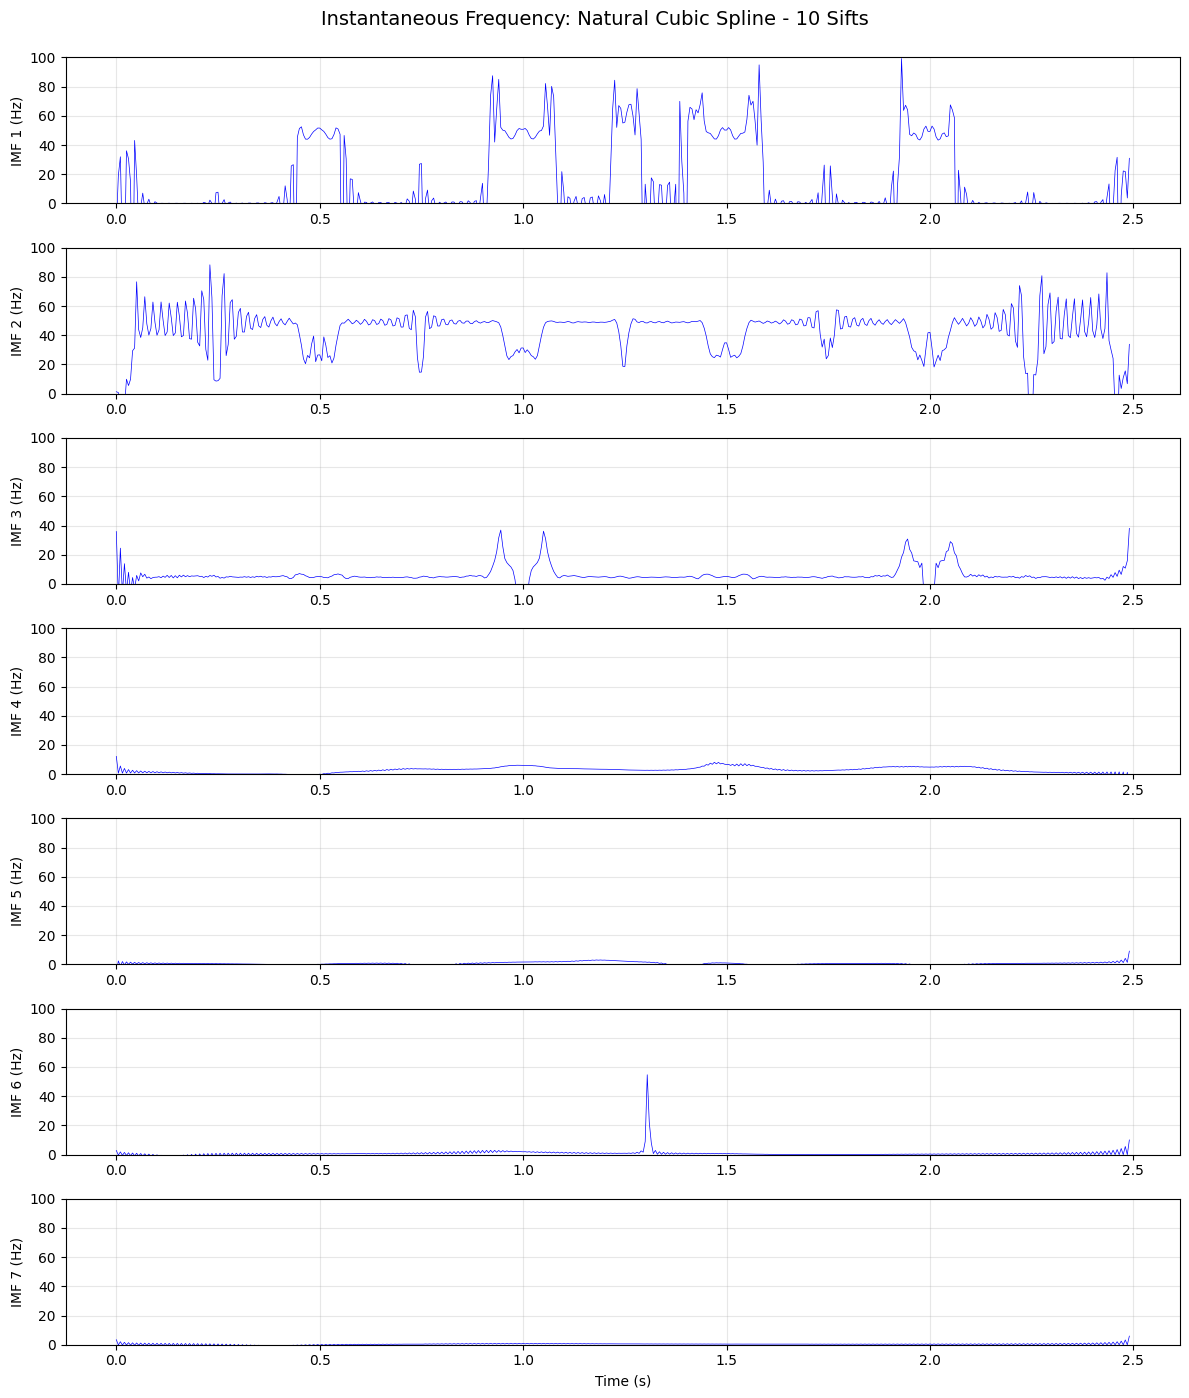


2. Natural Cubic Spline - Default Stopping:


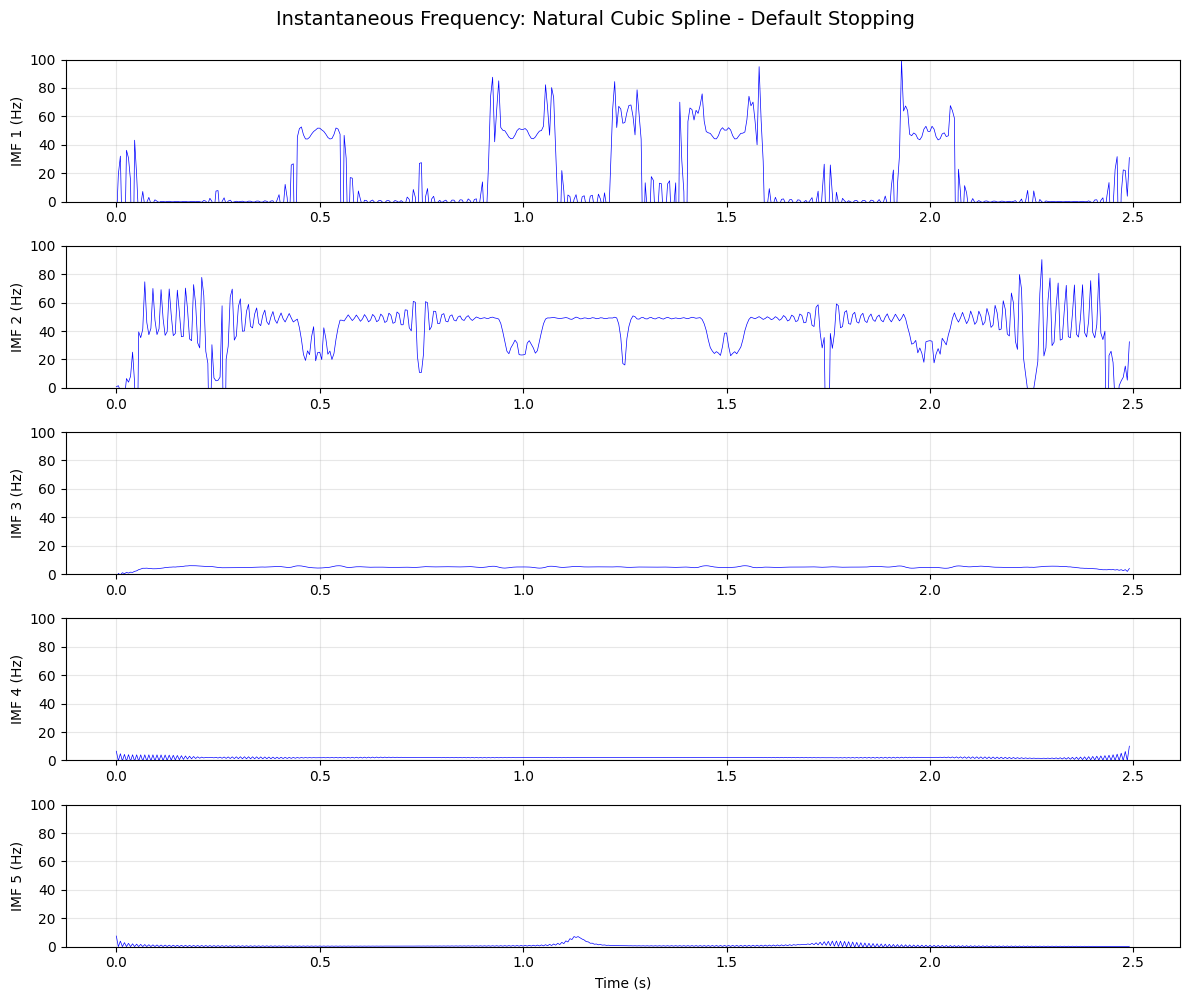


3. Hermite (PCHIP) Spline - 10 Sifts:


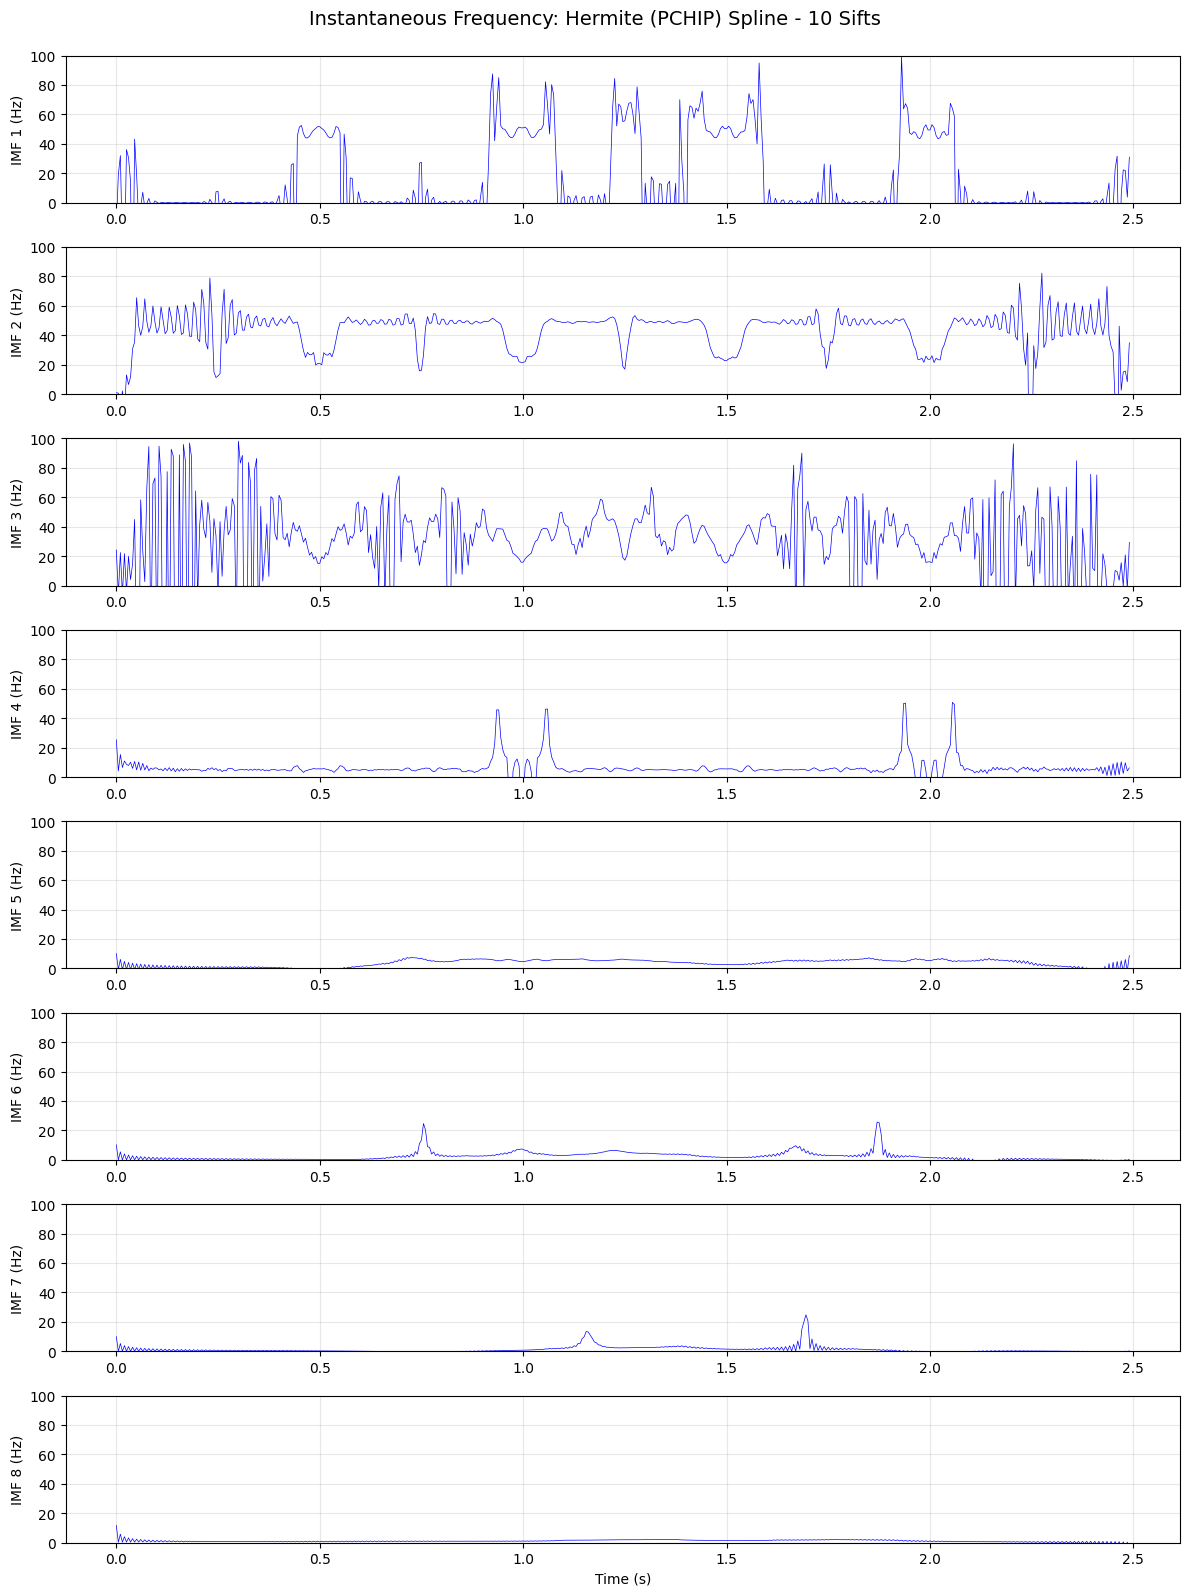


4. Hermite (PCHIP) Spline - Default Stopping:


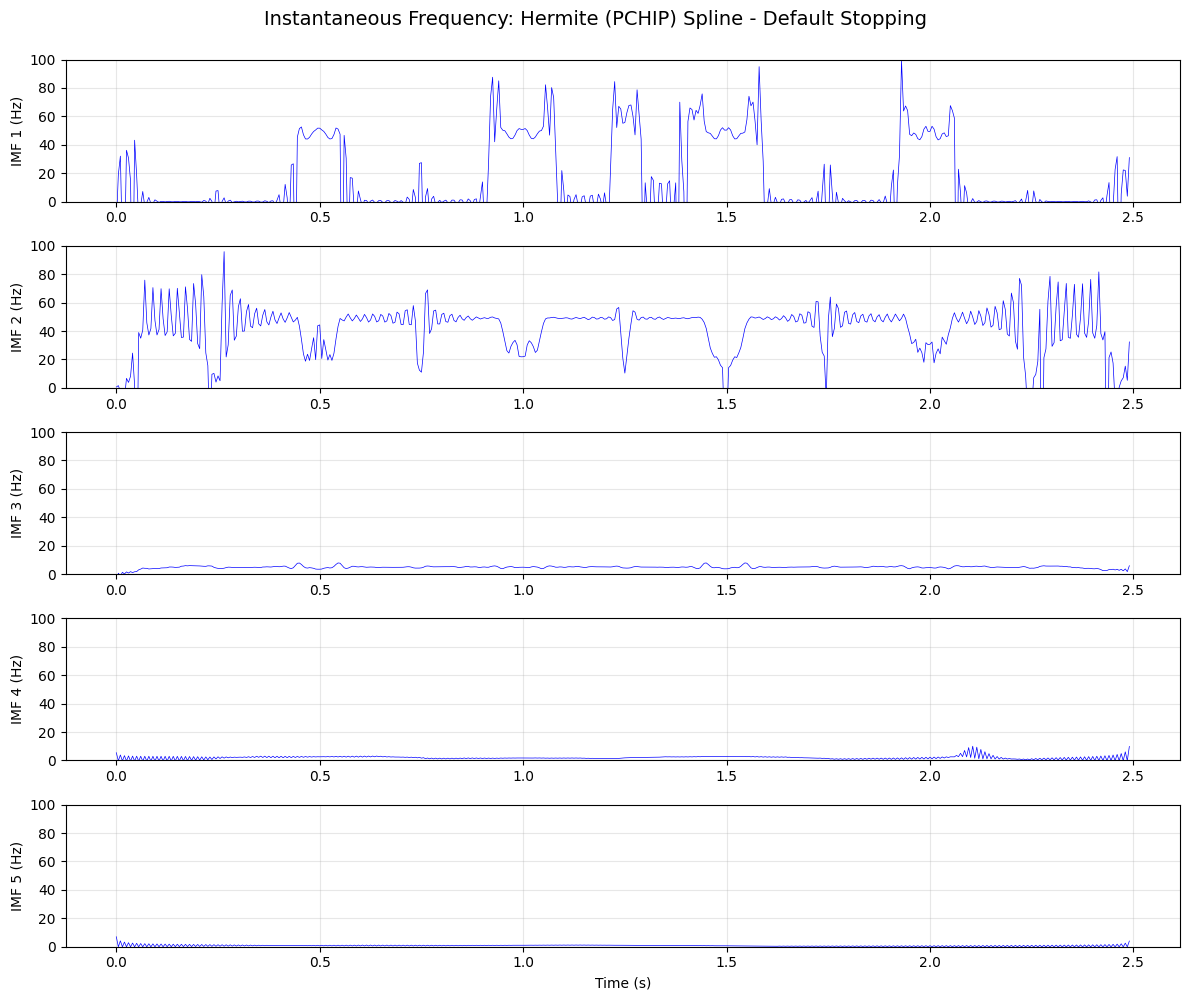

In [37]:
def compute_instantaneous_frequency(signal, sr):
    """Compute instantaneous frequency using Hilbert transform."""
    analytic_signal = hilbert(signal)
    instantaneous_phase = np.unwrap(np.angle(analytic_signal))
    instantaneous_frequency = np.diff(instantaneous_phase) * sr / (2 * np.pi)
    return instantaneous_frequency

def plot_instantaneous_frequencies(imfs, time_vector, sr, title_prefix="Instantaneous Frequency"):
    """Plot instantaneous frequency for all IMFs."""
    n_imfs = len(imfs)
    fig, axes = plt.subplots(n_imfs, 1, figsize=(12, 2*n_imfs))
    
    if n_imfs == 1:
        axes = [axes]
    
    for i, imf in enumerate(imfs):
        inst_freq = compute_instantaneous_frequency(imf, sr)
        axes[i].plot(time_vector[:-1], inst_freq, 'b-', linewidth=0.5)
        axes[i].set_ylabel(f'IMF {i+1} (Hz)')
        axes[i].set_ylim([0, 100])
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle(title_prefix, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

# Plot instantaneous frequencies for all 4 conditions
print("1. Natural Cubic Spline - 10 Sifts:")
plot_instantaneous_frequencies(imfs_cubic_10, time_vector, sr, 
                               "Instantaneous Frequency: Natural Cubic Spline - 10 Sifts")

print("\n2. Natural Cubic Spline - Default Stopping:")
plot_instantaneous_frequencies(imfs_cubic_default, time_vector, sr,
                               "Instantaneous Frequency: Natural Cubic Spline - Default Stopping")

print("\n3. Hermite (PCHIP) Spline - 10 Sifts:")
plot_instantaneous_frequencies(imfs_pchip_10, time_vector, sr,
                               "Instantaneous Frequency: Hermite (PCHIP) Spline - 10 Sifts")

print("\n4. Hermite (PCHIP) Spline - Default Stopping:")
plot_instantaneous_frequencies(imfs_pchip_default, time_vector, sr,
                               "Instantaneous Frequency: Hermite (PCHIP) Spline - Default Stopping")

## Analysis with Added Noise and Offset

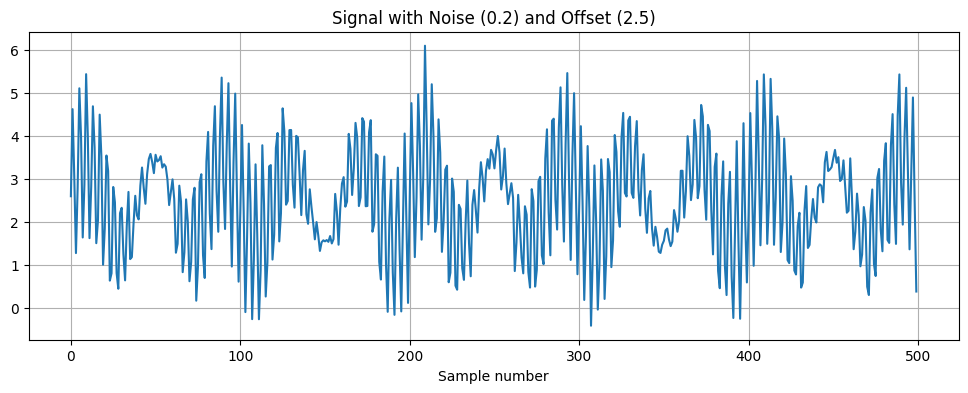

In [38]:
# Generate signal with noise and offset
np.random.seed(42)  # For reproducibility
signal_noisy = add_white_noise(signal, noise_level=0.2)
signal_noisy_offset = signal_noisy + 2.5

plotSignal(signal_noisy_offset, 'Signal with Noise (0.2) and Offset (2.5)')

### 1. Natural Cubic Spline - 10 Sifts (with Noise and Offset)

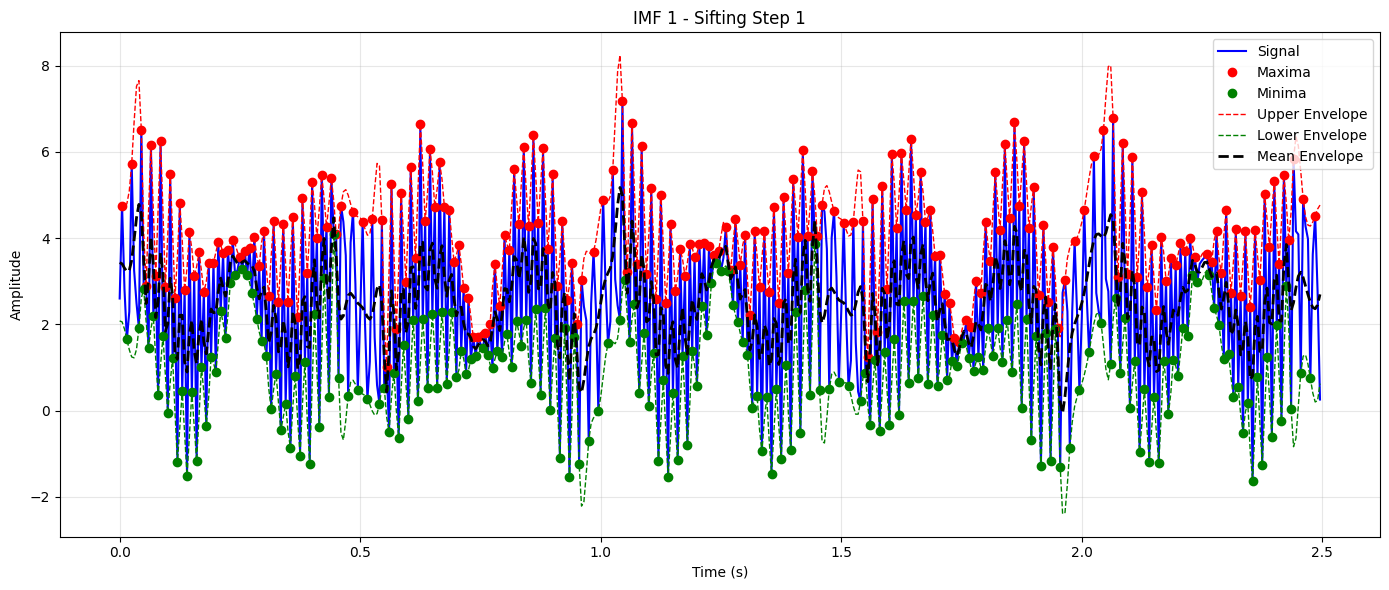

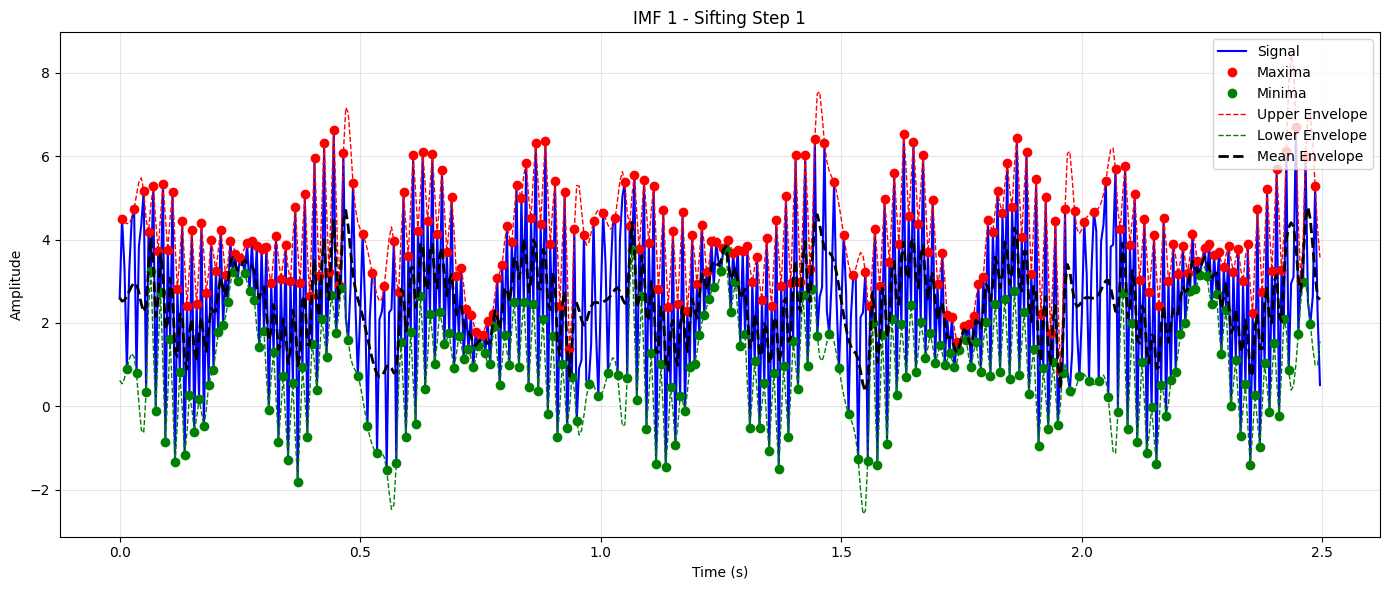

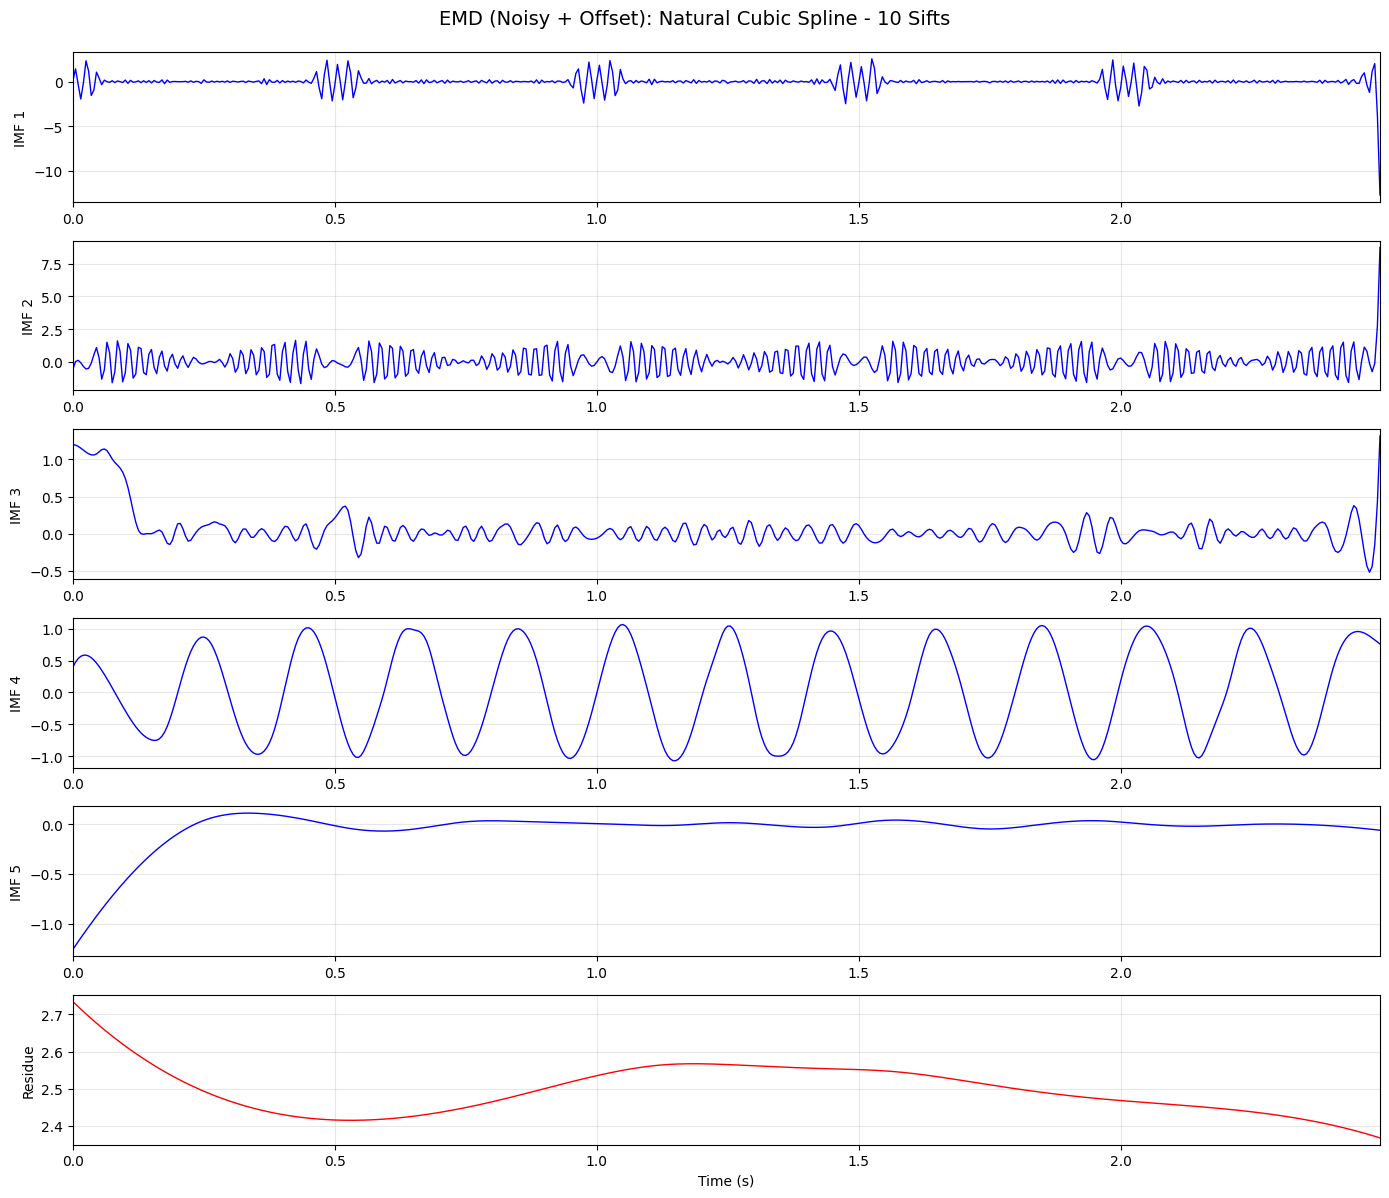

Number of IMFs extracted: 5


In [39]:
# EMD on noisy signal with Natural Cubic Spline, 10 sifts
imfs_noisy_cubic_10, residue_noisy_cubic_10 = emd(signal_noisy_offset, time_vector, 
                                                    max_sifts=10, 
                                                    spline_type='cubic',
                                                    use_default_stopping=False,
                                                    visualize_first_imf=True)

n_imfs = plot_imfs(imfs_noisy_cubic_10, residue_noisy_cubic_10, time_vector,
                   "EMD (Noisy + Offset): Natural Cubic Spline - 10 Sifts")
print(f"Number of IMFs extracted: {n_imfs}")

### 2. Natural Cubic Spline - Default Stopping (with Noise and Offset)

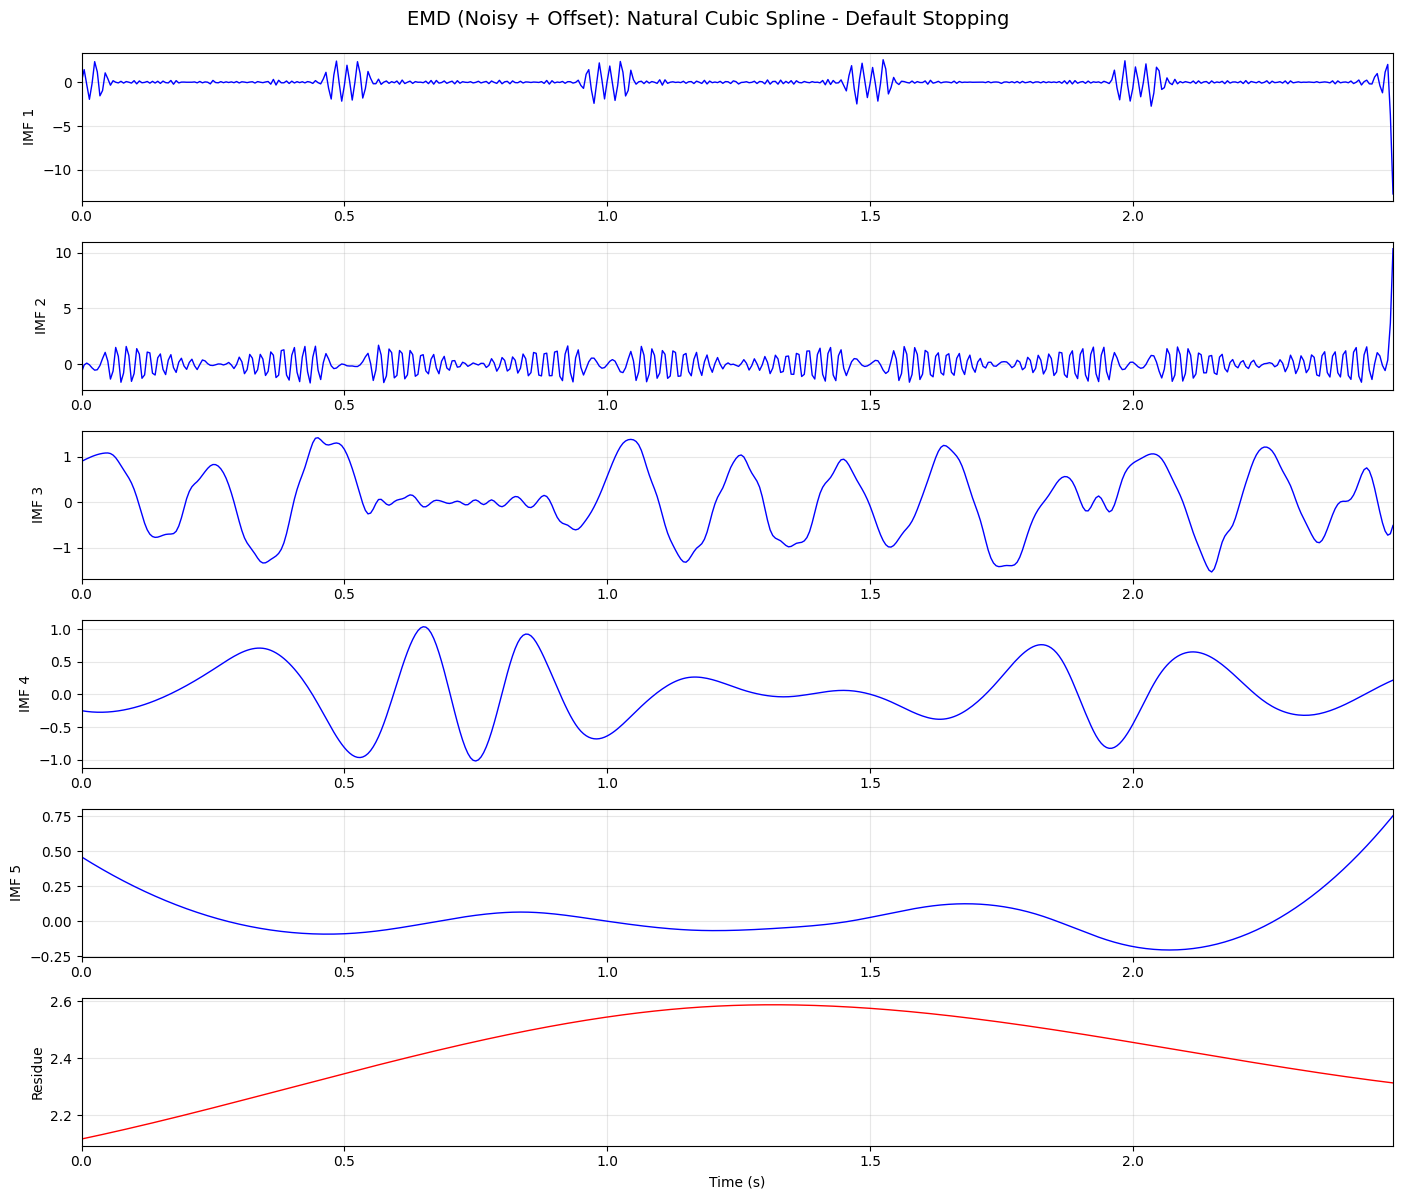

Number of IMFs extracted: 5


In [40]:
# EMD on noisy signal with Natural Cubic Spline, default stopping
imfs_noisy_cubic_default, residue_noisy_cubic_default = emd(signal_noisy_offset, time_vector,
                                                              spline_type='cubic',
                                                              use_default_stopping=True)

n_imfs = plot_imfs(imfs_noisy_cubic_default, residue_noisy_cubic_default, time_vector,
                   "EMD (Noisy + Offset): Natural Cubic Spline - Default Stopping")
print(f"Number of IMFs extracted: {n_imfs}")

### 3. Hermite (PCHIP) Spline - 10 Sifts (with Noise and Offset)

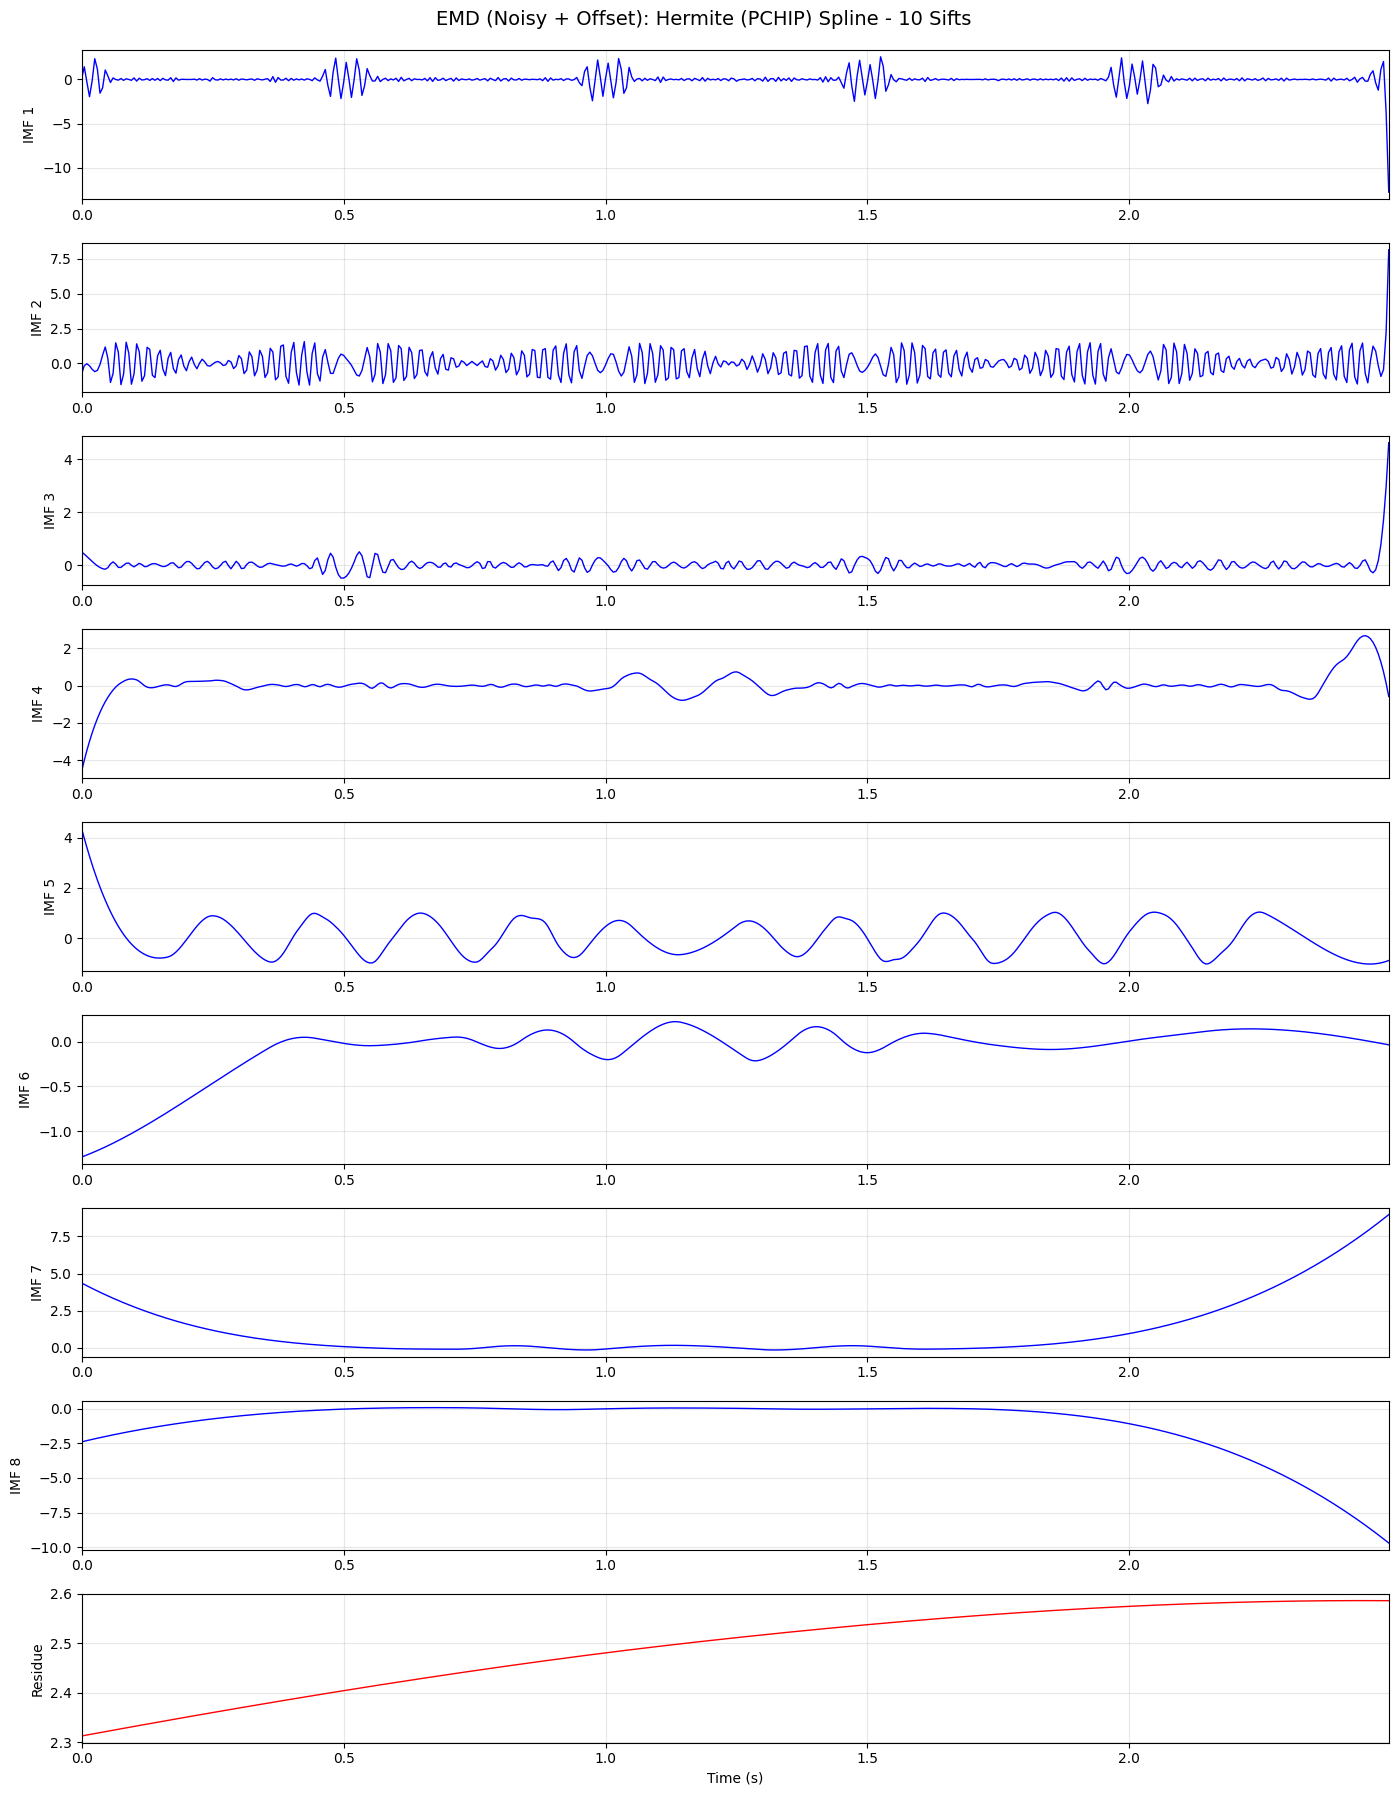

Number of IMFs extracted: 8


In [41]:
# EMD on noisy signal with Hermite (PCHIP) Spline, 10 sifts
imfs_noisy_pchip_10, residue_noisy_pchip_10 = emd(signal_noisy_offset, time_vector,
                                                    max_sifts=10,
                                                    spline_type='pchip',
                                                    use_default_stopping=False)

n_imfs = plot_imfs(imfs_noisy_pchip_10, residue_noisy_pchip_10, time_vector,
                   "EMD (Noisy + Offset): Hermite (PCHIP) Spline - 10 Sifts")
print(f"Number of IMFs extracted: {n_imfs}")

### 4. Hermite (PCHIP) Spline - Default Stopping (with Noise and Offset)

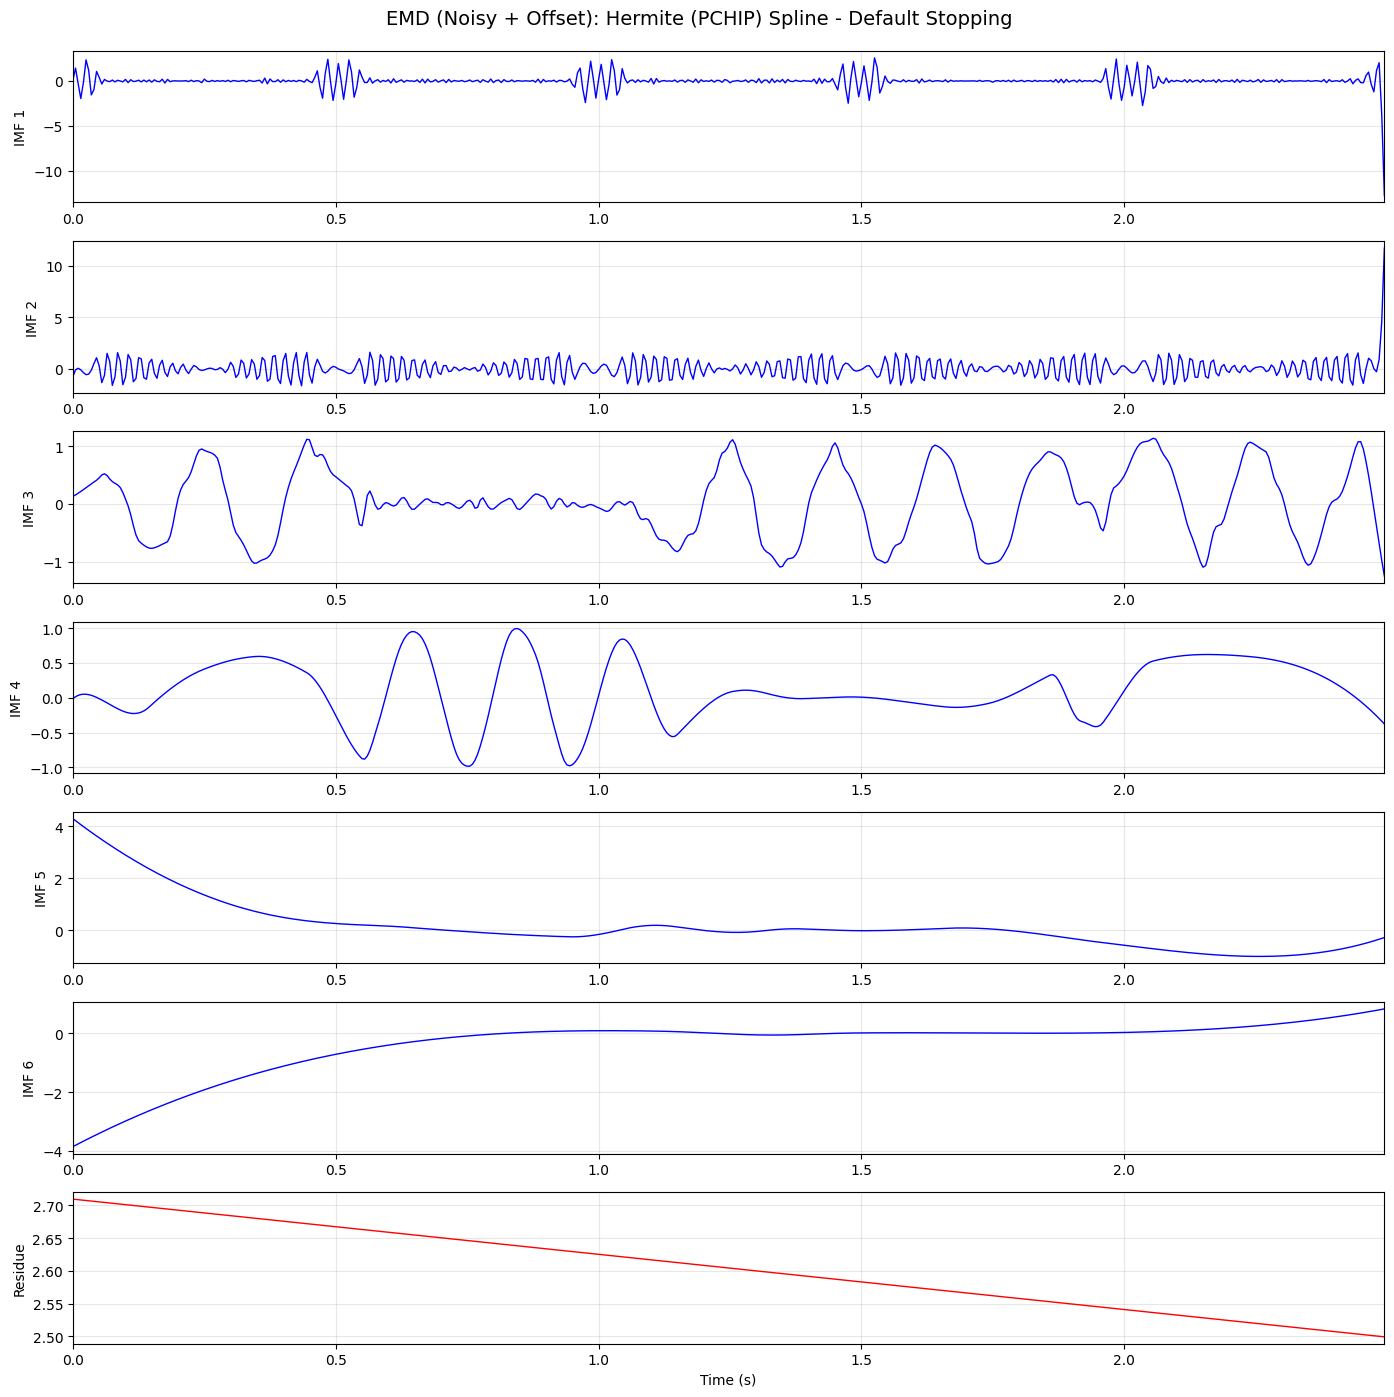

Number of IMFs extracted: 6


In [42]:
# EMD on noisy signal with Hermite (PCHIP) Spline, default stopping
imfs_noisy_pchip_default, residue_noisy_pchip_default = emd(signal_noisy_offset, time_vector,
                                                              spline_type='pchip',
                                                              use_default_stopping=True)

n_imfs = plot_imfs(imfs_noisy_pchip_default, residue_noisy_pchip_default, time_vector,
                   "EMD (Noisy + Offset): Hermite (PCHIP) Spline - Default Stopping")
print(f"Number of IMFs extracted: {n_imfs}")

### FFT Analysis (with Noise and Offset)

1. Natural Cubic Spline - 10 Sifts (with Noise and Offset):


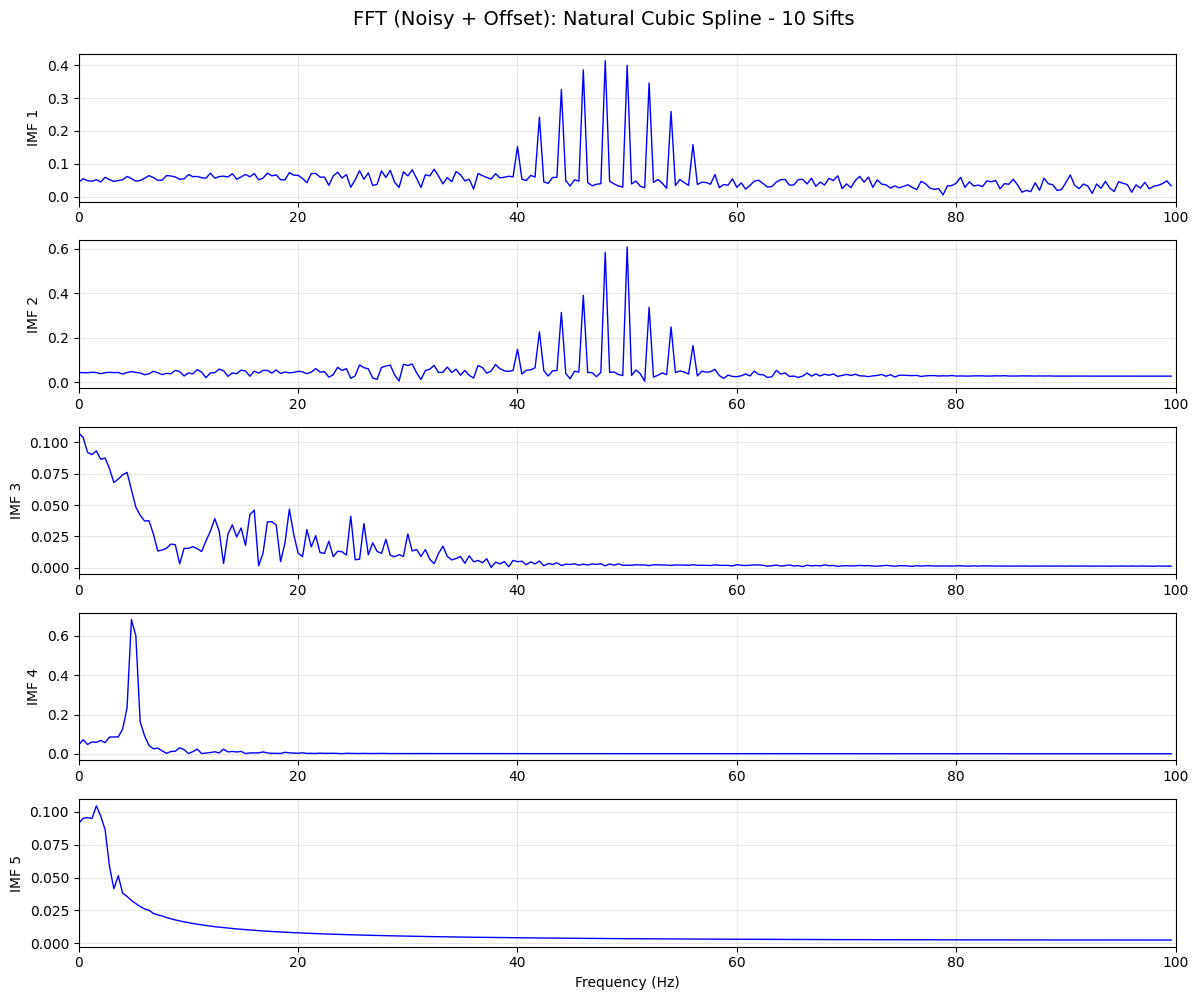


2. Natural Cubic Spline - Default Stopping (with Noise and Offset):


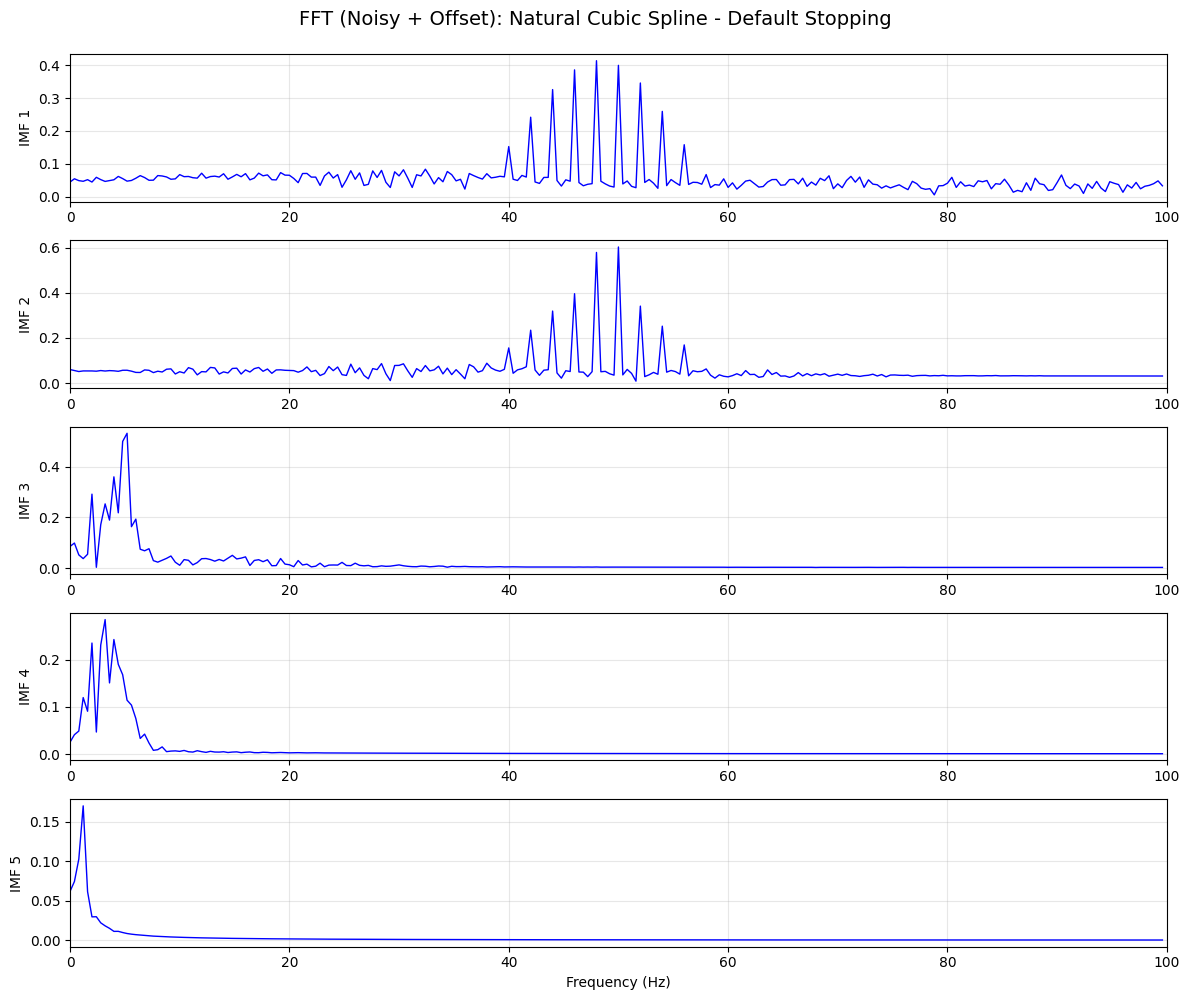


3. Hermite (PCHIP) Spline - 10 Sifts (with Noise and Offset):


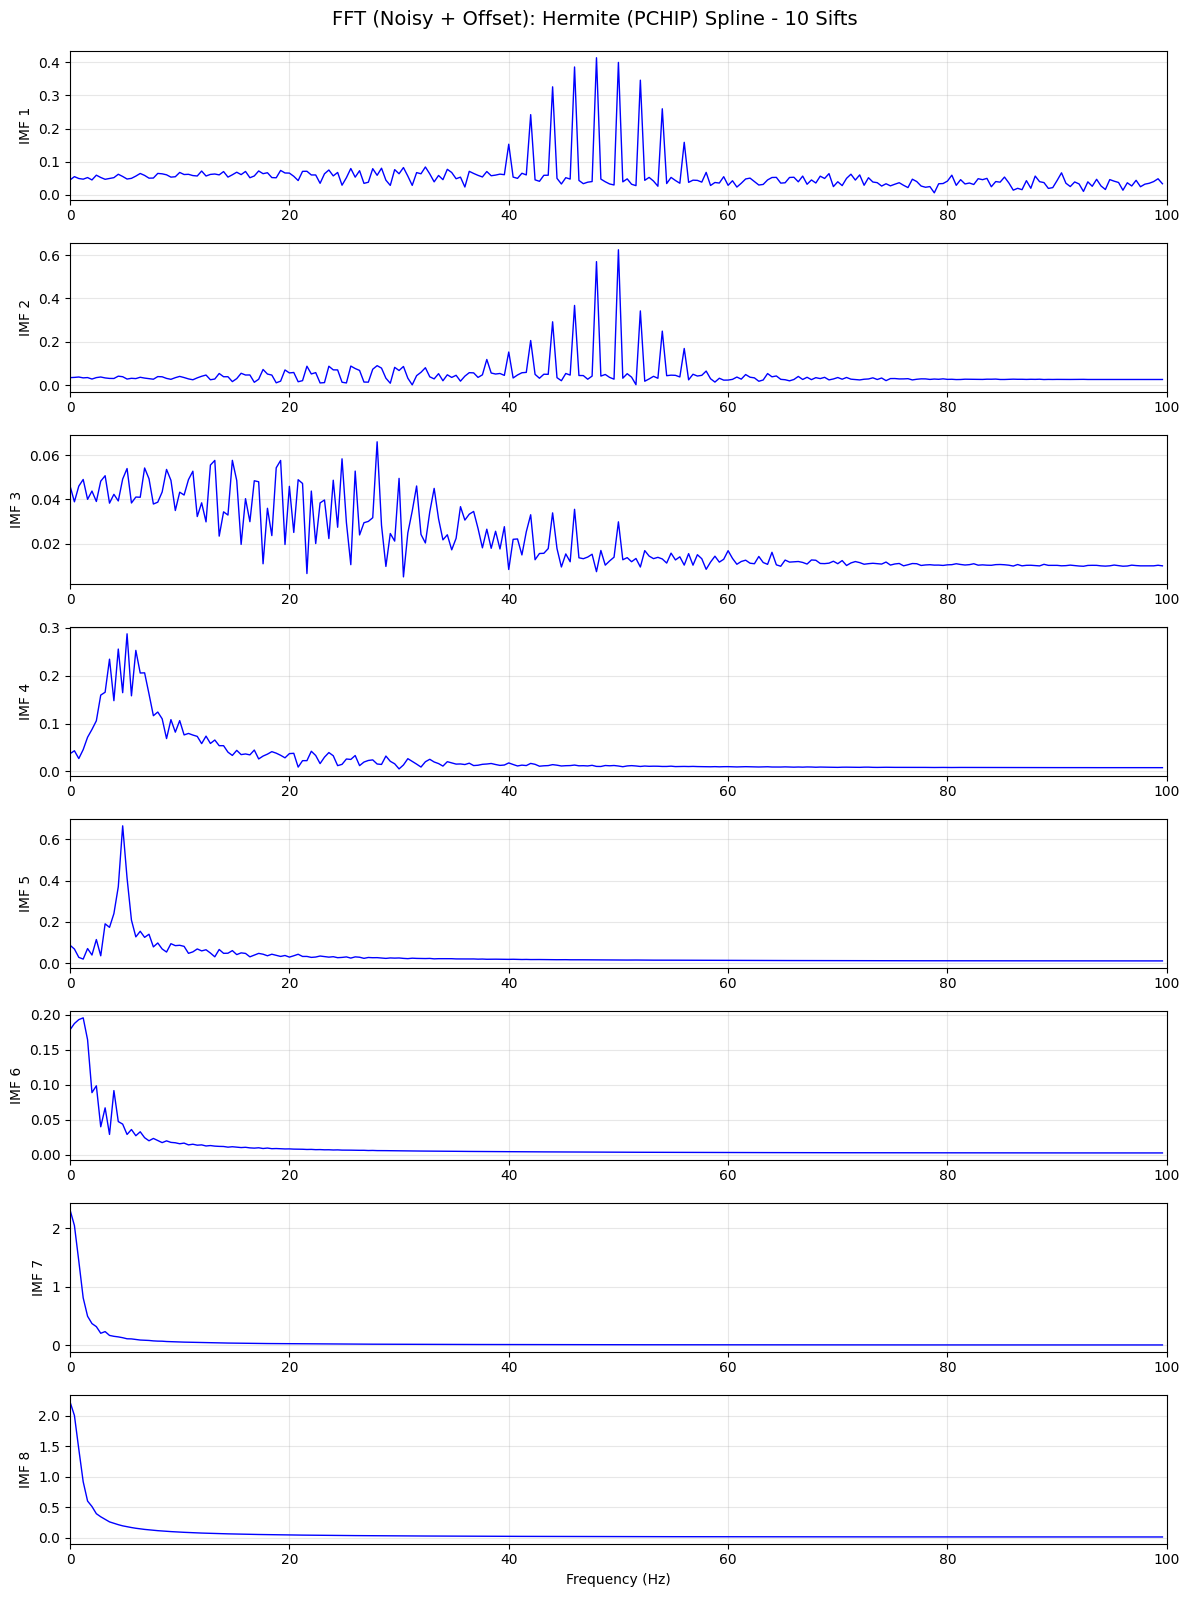


4. Hermite (PCHIP) Spline - Default Stopping (with Noise and Offset):


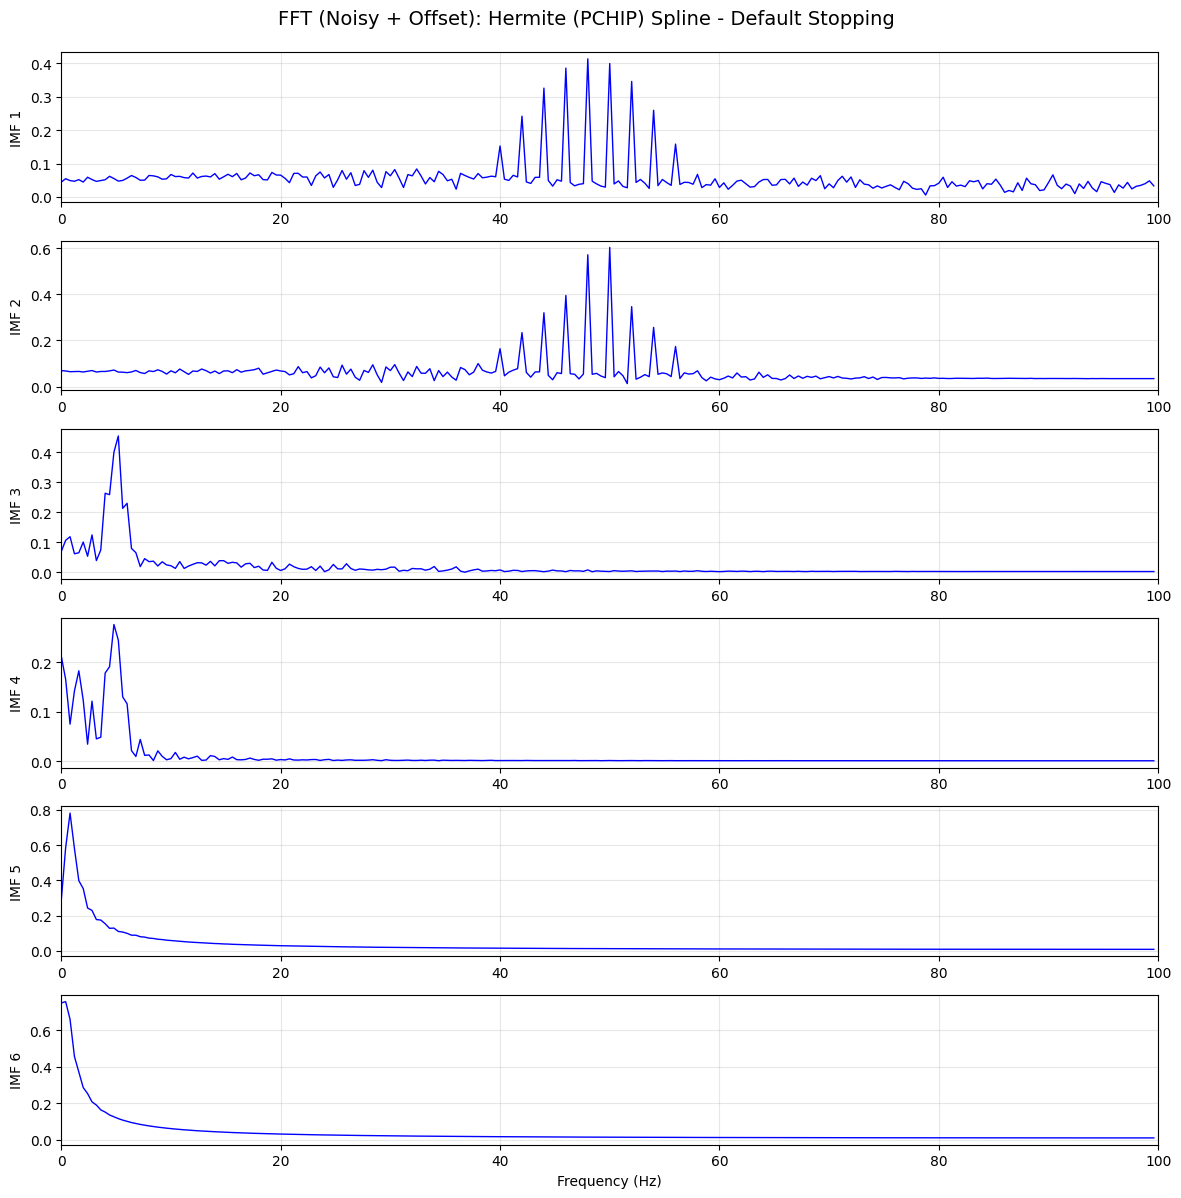

In [43]:
# Plot FFTs for all 4 noisy signal conditions
print("1. Natural Cubic Spline - 10 Sifts (with Noise and Offset):")
plot_imf_ffts(imfs_noisy_cubic_10, sr, "FFT (Noisy + Offset): Natural Cubic Spline - 10 Sifts")

print("\n2. Natural Cubic Spline - Default Stopping (with Noise and Offset):")
plot_imf_ffts(imfs_noisy_cubic_default, sr, "FFT (Noisy + Offset): Natural Cubic Spline - Default Stopping")

print("\n3. Hermite (PCHIP) Spline - 10 Sifts (with Noise and Offset):")
plot_imf_ffts(imfs_noisy_pchip_10, sr, "FFT (Noisy + Offset): Hermite (PCHIP) Spline - 10 Sifts")

print("\n4. Hermite (PCHIP) Spline - Default Stopping (with Noise and Offset):")
plot_imf_ffts(imfs_noisy_pchip_default, sr, "FFT (Noisy + Offset): Hermite (PCHIP) Spline - Default Stopping")

### Instantaneous Frequency Analysis (with Noise and Offset)

1. Natural Cubic Spline - 10 Sifts (with Noise and Offset):


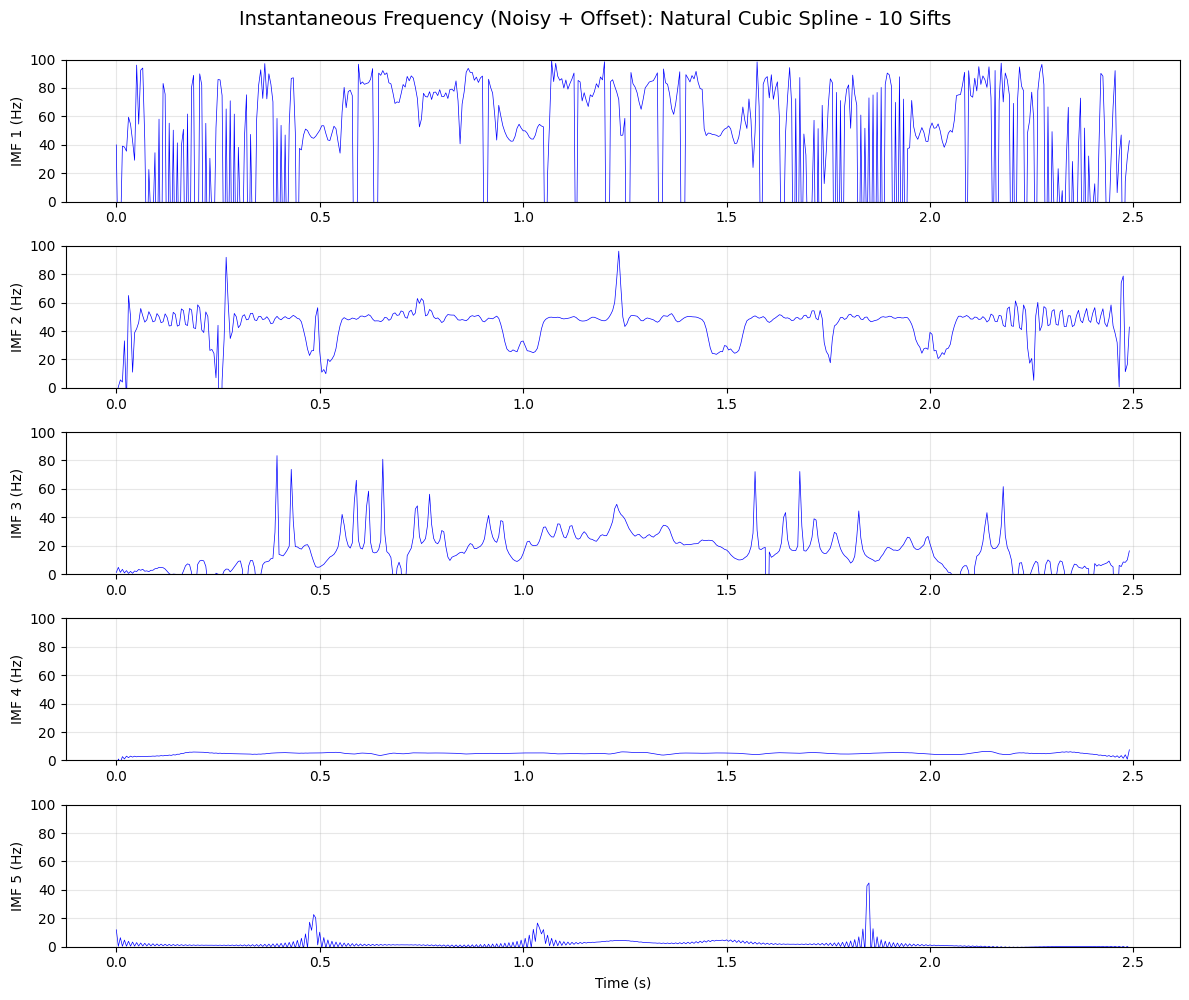


2. Natural Cubic Spline - Default Stopping (with Noise and Offset):


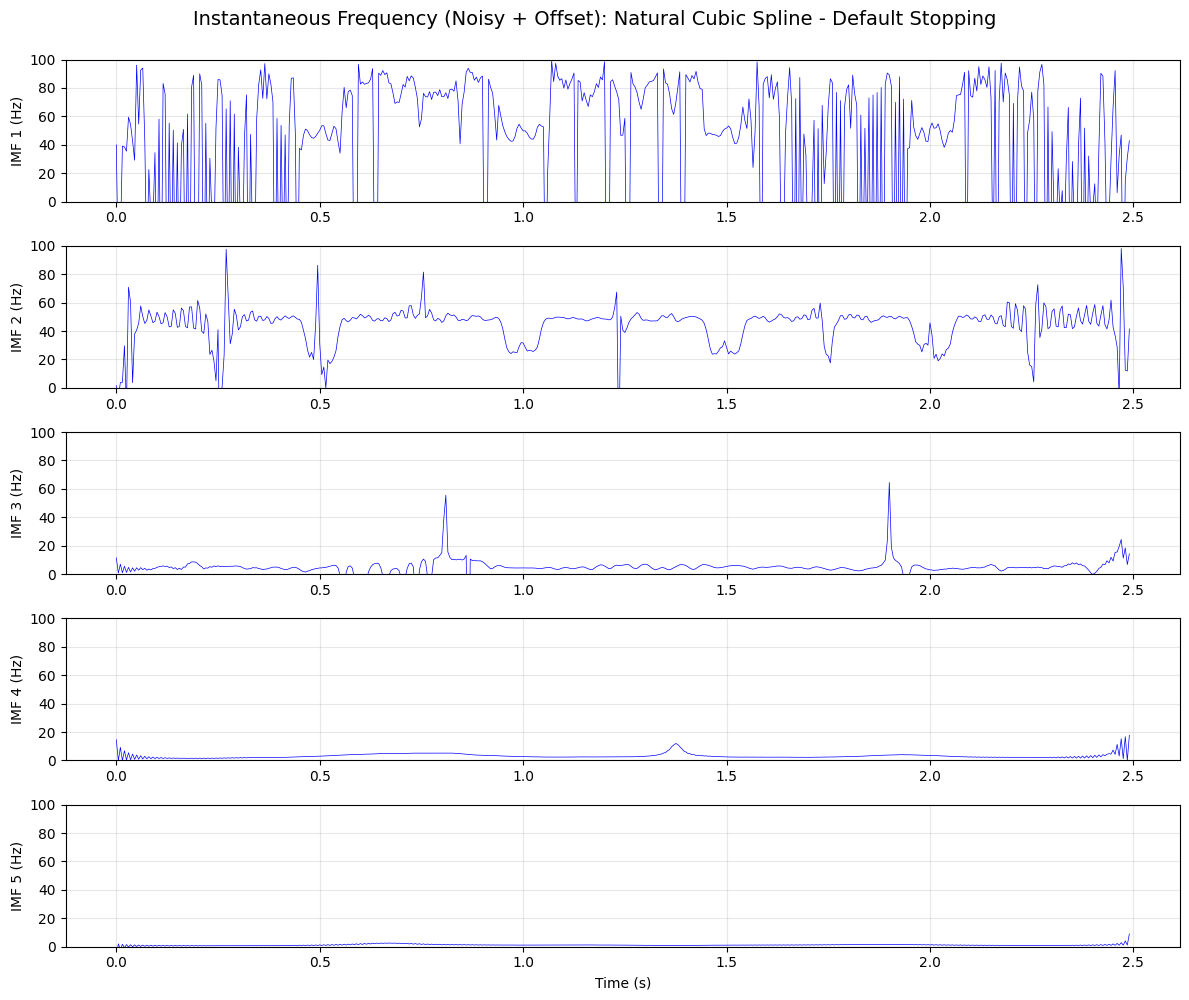


3. Hermite (PCHIP) Spline - 10 Sifts (with Noise and Offset):


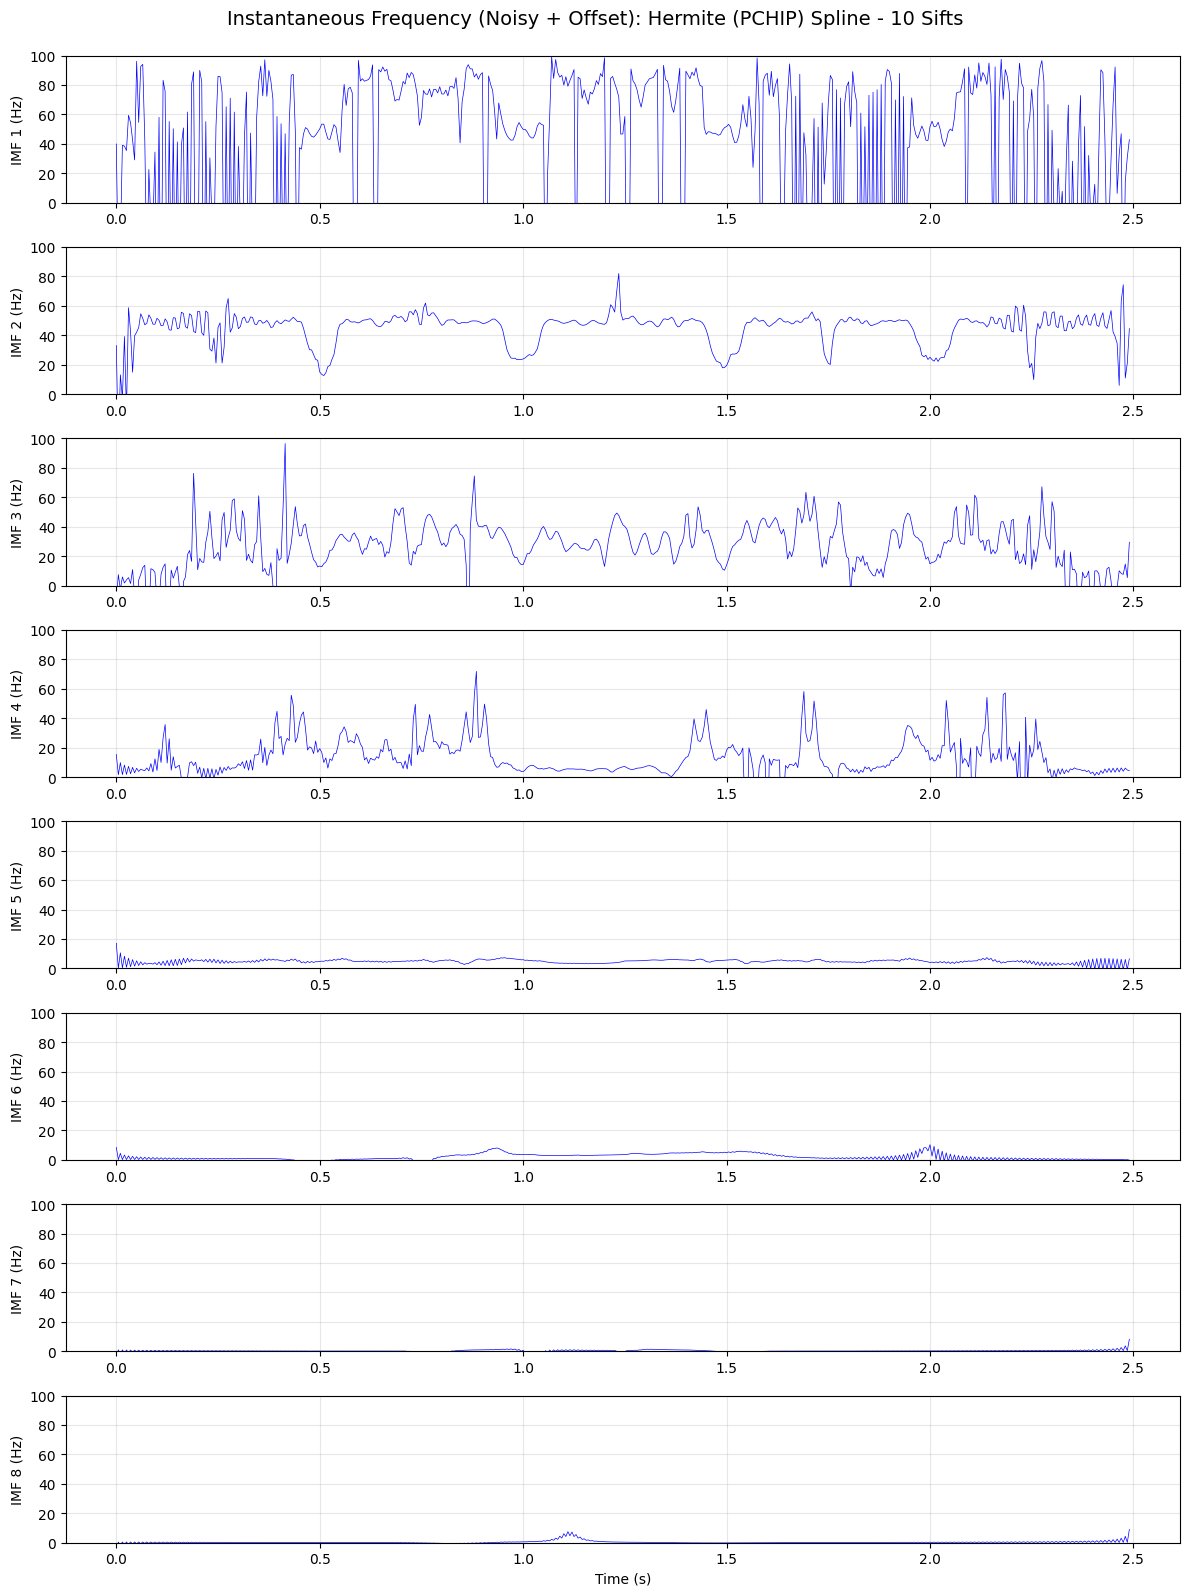


4. Hermite (PCHIP) Spline - Default Stopping (with Noise and Offset):


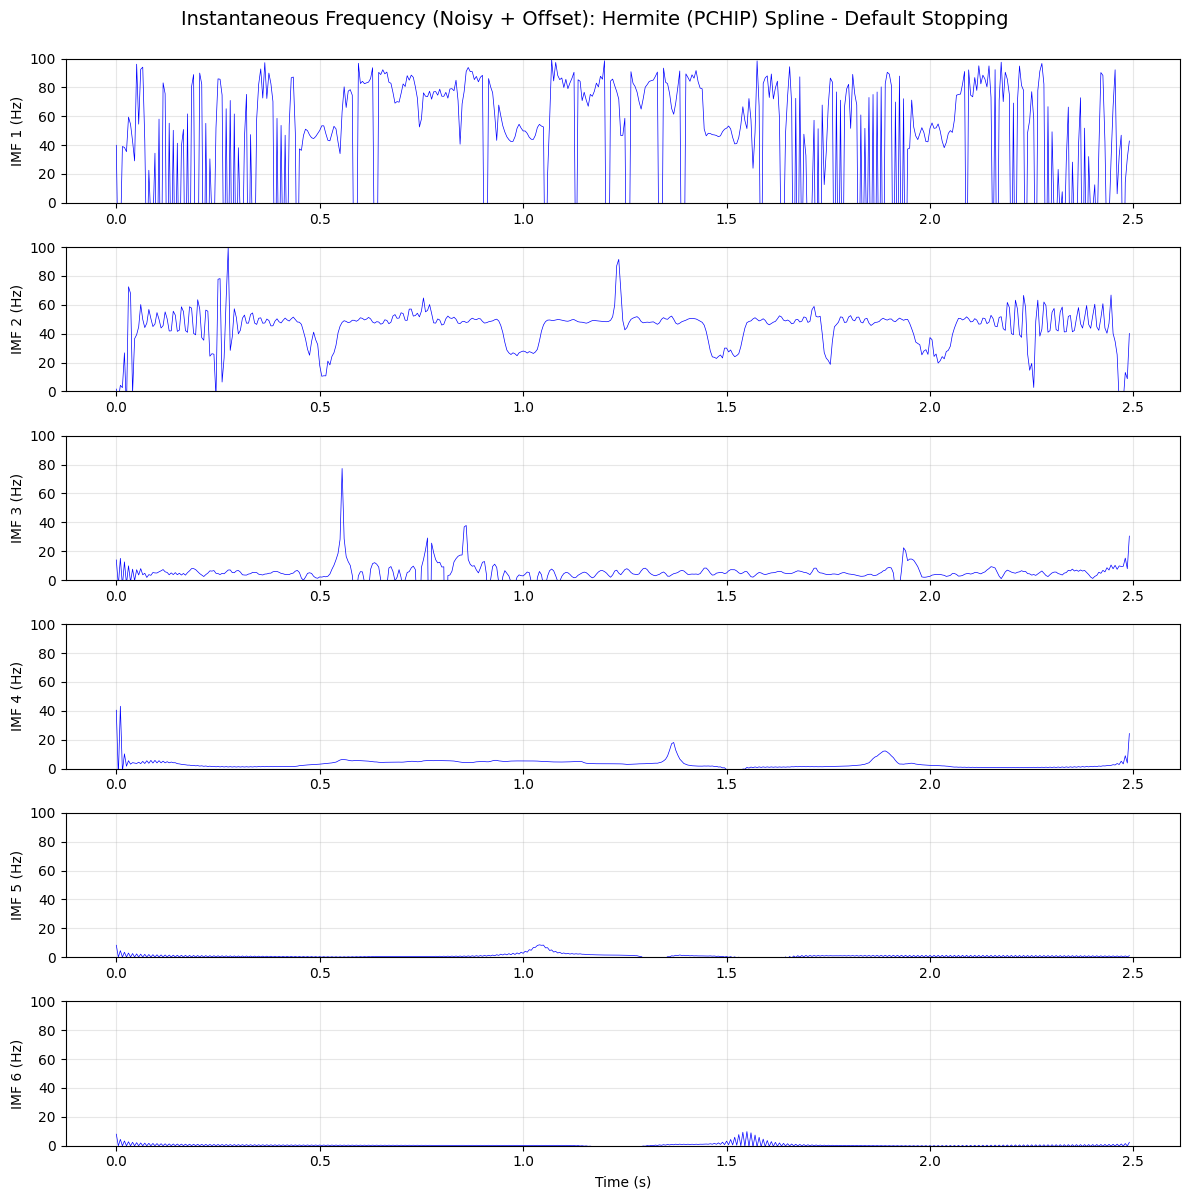

In [44]:
# Plot instantaneous frequencies for all 4 noisy signal conditions
print("1. Natural Cubic Spline - 10 Sifts (with Noise and Offset):")
plot_instantaneous_frequencies(imfs_noisy_cubic_10, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Natural Cubic Spline - 10 Sifts")

print("\n2. Natural Cubic Spline - Default Stopping (with Noise and Offset):")
plot_instantaneous_frequencies(imfs_noisy_cubic_default, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Natural Cubic Spline - Default Stopping")

print("\n3. Hermite (PCHIP) Spline - 10 Sifts (with Noise and Offset):")
plot_instantaneous_frequencies(imfs_noisy_pchip_10, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Hermite (PCHIP) Spline - 10 Sifts")

print("\n4. Hermite (PCHIP) Spline - Default Stopping (with Noise and Offset):")
plot_instantaneous_frequencies(imfs_noisy_pchip_default, time_vector, sr,
                               "Instantaneous Frequency (Noisy + Offset): Hermite (PCHIP) Spline - Default Stopping")